# [PBT] 모델링 전 국가별 데이터셋 전처리
## #01. 준비작업
### 1-1. 라이브러리 참조

In [1]:
import sys
sys.path.append("D:\\")

from IPython.display import display, Markdown
from pandas import DataFrame, crosstab
from helpers import * 

### 1-2. 파일 불러오기

In [2]:
import pandas as pd

df = pd.read_excel("토픽분류_데이터셋.xlsx")

display(df.head())
display(df.tail())

,리뷰_번호,국가,제품_순위,별점,Y,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
0,RU_P01_0001,러시아,1,5,1,0,0,1,0,1,0,1,0,0
1,RU_P01_0002,러시아,1,5,1,1,0,0,0,0,0,0,0,0
2,RU_P01_0003,러시아,1,5,1,1,1,0,0,1,0,1,0,0
3,RU_P01_0004,러시아,1,5,1,0,0,0,0,0,0,0,0,0
4,RU_P01_0005,러시아,1,5,1,0,1,1,0,1,1,0,0,0


,리뷰_번호,국가,제품_순위,별점,Y,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
7225,KR_P10_0196,한국,10,2,0,1,1,1,1,0,0,0,0,0
7226,KR_P10_0197,한국,10,2,0,0,0,1,1,0,0,0,0,0
7227,KR_P10_0198,한국,10,2,0,0,0,0,1,0,0,0,0,0
7228,KR_P10_0199,한국,10,2,0,1,0,0,1,0,0,0,0,0
7229,KR_P10_0200,한국,10,2,0,1,0,0,0,0,0,0,0,0


### 1-3. 컬럼 의미를 정리한 딕셔너리

In [3]:
column_means = {
    "리뷰_번호": "'국가 코드(러시아->RU, 미국->US, 일본->JP, 한국->KR)'_'제품 순위'_'리뷰 한 건'의 조합 구분자",
    "국가":    "러시아, 미국, 일본, 한국",
    "제품 순위":      "각 국가의 대표 플랫폼에서 수집한 스킨케어 크림 제품 인기 상위 순위. 1~10위",
    "Y":        "소비자의 제품 만족 여부. 0=불만족(별점 1·2점) / 1=만족(별점 4·5점) / 별점 3점은 제거",
    "보습":         "크림 제품의 보습력",
    "향":         "제품의 향",
    "발림성":       "제품의 제형·사용 후 느낌·흡수력",
    "자극":       "제품의 피부 자극·트러블 생성",
    "용기":      "제품 용기의 디자인, 패키지 구성, 밀봉력, 용량, 유통기한, 사용의 편리함",
    "배송":        "배송 속도, 제품 보존력, 주문 누락·오배송",
    "기능":       "제품의 효과",
    "가격":    "소비자가 느낀 비쌈/저렴함, 할인·쿠폰 적용 여부",
    "브랜드충성도":    "소비자의 브랜드 신뢰, 제품의 시리즈 선호, 이전 구매에서의 긍정적인 경험"
}

> 1행 = 리뷰 1건. 하나의 리뷰를 절 단위 조각으로 나누지 않음

> 9개의 토픽: 소비자의 만족도에 영향을 주는 각 요소가 리뷰에서 언급되었는지 여부(0=언급되지 않음/1=언급됨)

## #02. 데이터 품질 점검

### 2-1. 자료형 확인

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7230 entries, 0 to 7229
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   리뷰_번호   7230 non-null   str  
 1   국가      7230 non-null   str  
 2   제품_순위   7230 non-null   int64
 3   별점      7230 non-null   int64
 4   Y       7230 non-null   int64
 5   보습      7230 non-null   int64
 6   향       7230 non-null   int64
 7   발림성     7230 non-null   int64
 8   자극      7230 non-null   int64
 9   용기      7230 non-null   int64
 10  배송      7230 non-null   int64
 11  기능      7230 non-null   int64
 12  가격      7230 non-null   int64
 13  브랜드충성도  7230 non-null   int64
dtypes: int64(12), str(2)
memory usage: 916.3 KB


### 2-2. 데이터 타입 변환

In [5]:
df_typed = my_qtcheck.set_type(df, as_category=['국가', '제품_순위'])

<class 'pandas.DataFrame'>
RangeIndex: 7230 entries, 0 to 7229
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   리뷰_번호   7230 non-null   str     
 1   국가      7230 non-null   category
 2   제품_순위   7230 non-null   category
 3   별점      7230 non-null   int64   
 4   Y       7230 non-null   int64   
 5   보습      7230 non-null   int64   
 6   향       7230 non-null   int64   
 7   발림성     7230 non-null   int64   
 8   자극      7230 non-null   int64   
 9   용기      7230 non-null   int64   
 10  배송      7230 non-null   int64   
 11  기능      7230 non-null   int64   
 12  가격      7230 non-null   int64   
 13  브랜드충성도  7230 non-null   int64   
dtypes: category(2), int64(11), str(1)
memory usage: 769.9 KB


- 컬럼 중 `국가`·`제품_순위`를 **명목형(category)** 으로 변환한다.
 - `국가`: 고유값 4개(**러시아/미국/일본/한국**)를 가지는 명목형이다. 모델 투입 시엔 이후 원-핫 인코딩이 필요하므로 연속형으로 두면 안 된다.
 - `제품_순위`: 숫자 1~10(**인기순 상위 10개**)이지만 국가별로 다른 제품을 가리키는 **식별자 성격**이라 연속형으로 두면 안 된다. 명목형으로 취급 후 원-핫 인코딩 필요하다.

> `Y(종속변수)`: 이미 0/1 이진값이라 int 상태로도 sklearn에 바로 사용 가능. category로 바꿔도 되지만 필수는 아님

> `보습`·`향`·`발림성`·`자극`·`용기`·`배송`·`기능`·`가격` (토픽 8개): 변환 불필요(category로 바꿀 필요 없음). "언급 여부"를 나타내는 더미/이진 인디케이터라 이미 모델 투입 가능한 형태.    
다만 메모리 절약 목적이면 int64 → int8 또는 bool로 다운캐스팅은 고려 가능

### 2-3. 데이터 중복 점검

In [6]:
df_unique = my_qtcheck.check_duplicates(df_typed, drop=True)

print("중복 점검 후 :", df_unique.shape)

중복된 행의 수: 0
중복 점검 후 : (7230, 14)


### 2-4. 불필요한 컬럼 제거

| 컬럼 | 처리 |
|---|---|
| `리뷰_번호` | **행마다 고유한 ID**이므로 category로 바꿔도 이득이 없고, 모델링 피처에서는 제외(드롭) 대상 |
| `별점` | Y가 별점에서 그대로 파생된 값(1·2점→0, 4·5점→1)이라 피처로 쓰면 데이터 누수(leakage) 발생 → category 변환이 아니라 컬럼 자체를 드롭 |

In [7]:
# 중복이 없었으므로 행 수는 그대로다. 여기서 분석에 쓸 수 없는 컬럼만 떨어낸다.
# -> `국가` 는 파생변수(국가x속성)의 재료이므로 여기서 지우지 않는다 (#03.5 에서 제거)
df_dropped = df_unique.drop(columns=["리뷰_번호", "별점"])

df_dropped.info()

<class 'pandas.DataFrame'>
RangeIndex: 7230 entries, 0 to 7229
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   국가      7230 non-null   category
 1   제품_순위   7230 non-null   category
 2   Y       7230 non-null   int64   
 3   보습      7230 non-null   int64   
 4   향       7230 non-null   int64   
 5   발림성     7230 non-null   int64   
 6   자극      7230 non-null   int64   
 7   용기      7230 non-null   int64   
 8   배송      7230 non-null   int64   
 9   기능      7230 non-null   int64   
 10  가격      7230 non-null   int64   
 11  브랜드충성도  7230 non-null   int64   
dtypes: category(2), int64(10)
memory usage: 579.2 KB


### 2-5. 결측치 점검

In [8]:
my_qtcheck.check_missing_values(df_dropped)

,Missing Count,Missing Ratio (%)
국가,0,0.0
제품_순위,0,0.0
Y,0,0.0
보습,0,0.0
향,0,0.0
발림성,0,0.0
자극,0,0.0
용기,0,0.0
배송,0,0.0
기능,0,0.0


### 2-6. 속성값이 모두 0인 행 개수 확인
- 토픽의 속성값이 모두 0이다: 소비자의 평가는 있으나, 분석가가 분류한 토픽이 리뷰에 언급되지 않음.


In [ ]:
cols = [
    '보습', '향', '발림성', '자극', 
    '용기', '배송', '기능', '가격', '브랜드충성도'
]

# 9개 속성이 모두 0인 행 찾기
# zero_rows 는 true/false 값을 갖는 1차원 series
zero_rows = (df_dropped[cols] == 0).all(axis=1)

# 전체 개수 확인
print("속성값이 모두 0인 행 개수:", zero_rows.sum())

# 국가별 개수 확인
print("\n국가별 속성값 전체 0인 행 개수:")
display(df_dropped.loc[zero_rows, '국가'].value_counts())

# 해당 행 직접 확인
display(df_dropped[zero_rows])

속성값이 모두 0인 행 개수: 417

국가별 속성값 전체 0인 행 개수:


국가
러시아    215
한국      89
미국      75
일본      38
Name: count, dtype: int64

,국가,제품_순위,Y,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
3,러시아,1,1,0,0,0,0,0,0,0,0,0
8,러시아,1,1,0,0,0,0,0,0,0,0,0
22,러시아,1,1,0,0,0,0,0,0,0,0,0
32,러시아,1,1,0,0,0,0,0,0,0,0,0
38,러시아,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7102,한국,10,1,0,0,0,0,0,0,0,0,0
7111,한국,10,1,0,0,0,0,0,0,0,0,0
7120,한국,10,1,0,0,0,0,0,0,0,0,0
7124,한국,10,1,0,0,0,0,0,0,0,0,0


### 2-7. 속성값이 모두 0인 행 제거

In [11]:
df_cleaned = df_dropped.loc[~zero_rows].copy()

print("삭제 전 행 개수:", len(df_dropped))
print("삭제 후 행 개수:", len(df_cleaned))
print("삭제된 행 개수:", len(df_dropped) - len(df_cleaned))

display(df_cleaned.head())

삭제 전 행 개수: 7230
삭제 후 행 개수: 6813
삭제된 행 개수: 417


,국가,제품_순위,Y,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
0,러시아,1,1,0,0,1,0,1,0,1,0,0
1,러시아,1,1,1,0,0,0,0,0,0,0,0
2,러시아,1,1,1,1,0,0,1,0,1,0,0
4,러시아,1,1,0,1,1,0,1,1,0,0,0
5,러시아,1,1,1,0,0,0,0,0,0,0,0


## #03. 도메인 지식에 기반한 파생변수 및 분석용 자료형 설정

In [12]:
## #03. 도메인 지식에 기반한 파생변수 추가

topic_cols = [
    '보습', '향', '발림성', '자극',
    '용기', '배송', '기능', '가격', '브랜드충성도'
]

# 속성 전체 0인 행을 제거한 데이터 사용
df_derived = df_cleaned.copy()

# 한 리뷰에서 몇 개의 속성이 언급되었는지
df_derived['토픽_언급수'] = df_derived[topic_cols].sum(axis=1)

column_means['토픽_언급수'] = '한 리뷰에서 언급된 9개 속성의 개수'

display(
    df_derived['토픽_언급수']
    .value_counts()
    .sort_index()
)

토픽_언급수
1    1468
2    2234
3    1836
4     979
5     237
6      49
7       9
8       1
Name: count, dtype: int64

# 03. 도메인 지식에 기반한 파생변수 추가

## 1. 토픽 언급 수 파생변수 생성

- 각 리뷰에서 9개 속성 중 몇 개의 속성이 언급되었는지 확인하기 위해 `토픽_언급수` 변수를 생성한다.
- 분석 대상 속성은 `보습`, `향`, `발림성`, `자극`, `용기`, `배송`, `기능`, `가격`, `브랜드충성도` 총 9개이다.
- 각 속성은 언급되지 않은 경우 `0`, 언급된 경우 `1`로 구성되어 있으므로, 9개 속성의 값을 합산하여 리뷰별 토픽 언급 수를 계산한다.
- 앞 단계에서 9개 속성이 모두 0인 리뷰를 제거하였으므로 `토픽_언급수`의 최솟값은 1이다.

### 토픽 언급 수 분포

- 1개 속성 언급: 1,468건
- 2개 속성 언급: 2,234건
- 3개 속성 언급: 1,836건
- 4개 속성 언급: 979건
- 5개 속성 언급: 237건
- 6개 속성 언급: 49건
- 7개 속성 언급: 9건
- 8개 속성 언급: 1건

대부분의 리뷰에서 2~3개의 속성이 함께 언급되는 경향을 확인할 수 있다.

`토픽_언급수`는 개별 속성의 효과를 대체하는 변수가 아니라, 리뷰 한 건에서 얼마나 다양한 속성이 함께 언급되었는지를 나타내는 보조 파생변수로 활용한다.

## #04. 결측치 최종 확인


In [13]:
my_qtcheck.check_missing_values(df_derived)

,Missing Count,Missing Ratio (%)
국가,0,0.0
제품_순위,0,0.0
Y,0,0.0
보습,0,0.0
향,0,0.0
발림성,0,0.0
자극,0,0.0
용기,0,0.0
배송,0,0.0
기능,0,0.0


## #05. 기술통계량 확인


In [14]:

df_eda = df_derived.copy()

# EDA에서 범주형으로 사용할 변수
eda_category_cols = [
    'Y', '국가', '제품_순위',
    '보습', '향', '발림성', '자극',
    '용기', '배송', '기능', '가격', '브랜드충성도'
]

df_eda = my_qtcheck.set_type(
    df_eda,
    as_category=eda_category_cols
)

cat_desc = my_qtcheck.categorical_summary(
    df_eda,
    value_counts=False
)

cat_desc

<class 'pandas.DataFrame'>
Index: 6813 entries, 0 to 7229
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   국가      6813 non-null   category
 1   제품_순위   6813 non-null   category
 2   Y       6813 non-null   category
 3   보습      6813 non-null   category
 4   향       6813 non-null   category
 5   발림성     6813 non-null   category
 6   자극      6813 non-null   category
 7   용기      6813 non-null   category
 8   배송      6813 non-null   category
 9   기능      6813 non-null   category
 10  가격      6813 non-null   category
 11  브랜드충성도  6813 non-null   category
 12  토픽_언급수  6813 non-null   int64   
dtypes: category(12), int64(1)
memory usage: 186.8 KB


,국가,제품_순위,Y,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
count,6813,6813,6813,6813,6813,6813,6813,6813,6813,6813,6813,6813
unique,4,10,2,2,2,2,2,2,2,2,2,2
top,한국,8,1,0,0,0,0,0,0,0,0,0
freq,1850,747,4462,3714,5714,3660,3458,5421,6386,3897,6265,5892


# 05. 분석용 자료형 설정 및 기술통계 확인

## 1. EDA용 변수 자료형 설정

분석 목적에 맞게 EDA용 데이터프레임을 별도로 생성하고 변수의 자료형을 재설정하였다.

- 전체 분석 대상 데이터는 6,813건이다.
- 종속변수 `Y`, `국가`, `제품_순위` 및 9개 속성 변수는 범주형(`category`)으로 변환하였다.
- 속성 변수는 값이 0과 1로 구성되어 있으나, 수치의 크기를 의미하는 변수가 아니라 속성의 미언급(0)과 언급(1)을 나타내므로 범주형 변수로 처리하였다.
- `국가`와 `제품_순위` 역시 연속적인 크기나 순서를 의미하는 수치형 변수가 아니므로 범주형으로 처리하였다.
- `토픽_언급수`는 리뷰 한 건에서 언급된 속성의 개수를 의미하므로 수치형(`int64`)으로 유지하였다.
- 모든 변수의 Non-Null Count가 6,813건으로 동일하므로 현재 분석 데이터에는 결측치가 존재하지 않는다.

### 자료형 구성

- 범주형 변수: 12개
    - Y
    - 국가
    - 제품_순위
    - 보습
    - 향
    - 발림성
    - 자극
    - 용기
    - 배송
    - 기능
    - 가격
    - 브랜드충성도

- 수치형 변수: 1개
    - 토픽_언급수

따라서 이후 단변량 및 이변량 분석에서는 범주형 변수에 대해 빈도분석과 교차분석을 중심으로 수행하고, `토픽_언급수`는 수치형 파생변수로 별도 분석한다.

## #06. 변수 유형 분류와 EDA 범위


In [15]:

target = 'Y'
target_is_continuous = False

nominal_cols = my_qtcheck.get_categorical_column_names(df_eda)
continuous_cols = my_qtcheck.get_number_column_names(df_eda)

# 종속변수 제거
nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형 : 명목형(2집단)")
print("명목형 독립변수 :", nominal_cols)
print("연속형 독립변수 :", continuous_cols)

종속변수 : Y
종속변수 유형 : 명목형(2집단)
명목형 독립변수 : ['국가', '제품_순위', '보습', '향', '발림성', '자극', '용기', '배송', '기능', '가격', '브랜드충성도']
연속형 독립변수 : ['토픽_언급수']


# 06. 변수 유형 분류 및 EDA 범위 설정

- 종속변수 `Y`는 0과 1로 구성된 이진 범주형 변수이므로 명목형 변수로 설정하였다.
- 명목형 독립변수는 `국가`, `제품_순위` 및 9개 속성 변수로 구성된다.
- `토픽_언급수`는 리뷰별 속성 언급 개수를 나타내므로 수치형 변수로 분류하였다.
- 이후 명목형 변수는 빈도분석 및 교차분석을 중심으로 확인하고, 수치형 변수는 분포 및 그룹 간 차이를 확인한다.

## #07. 단변량 분석
### 1. 종속변수 Y


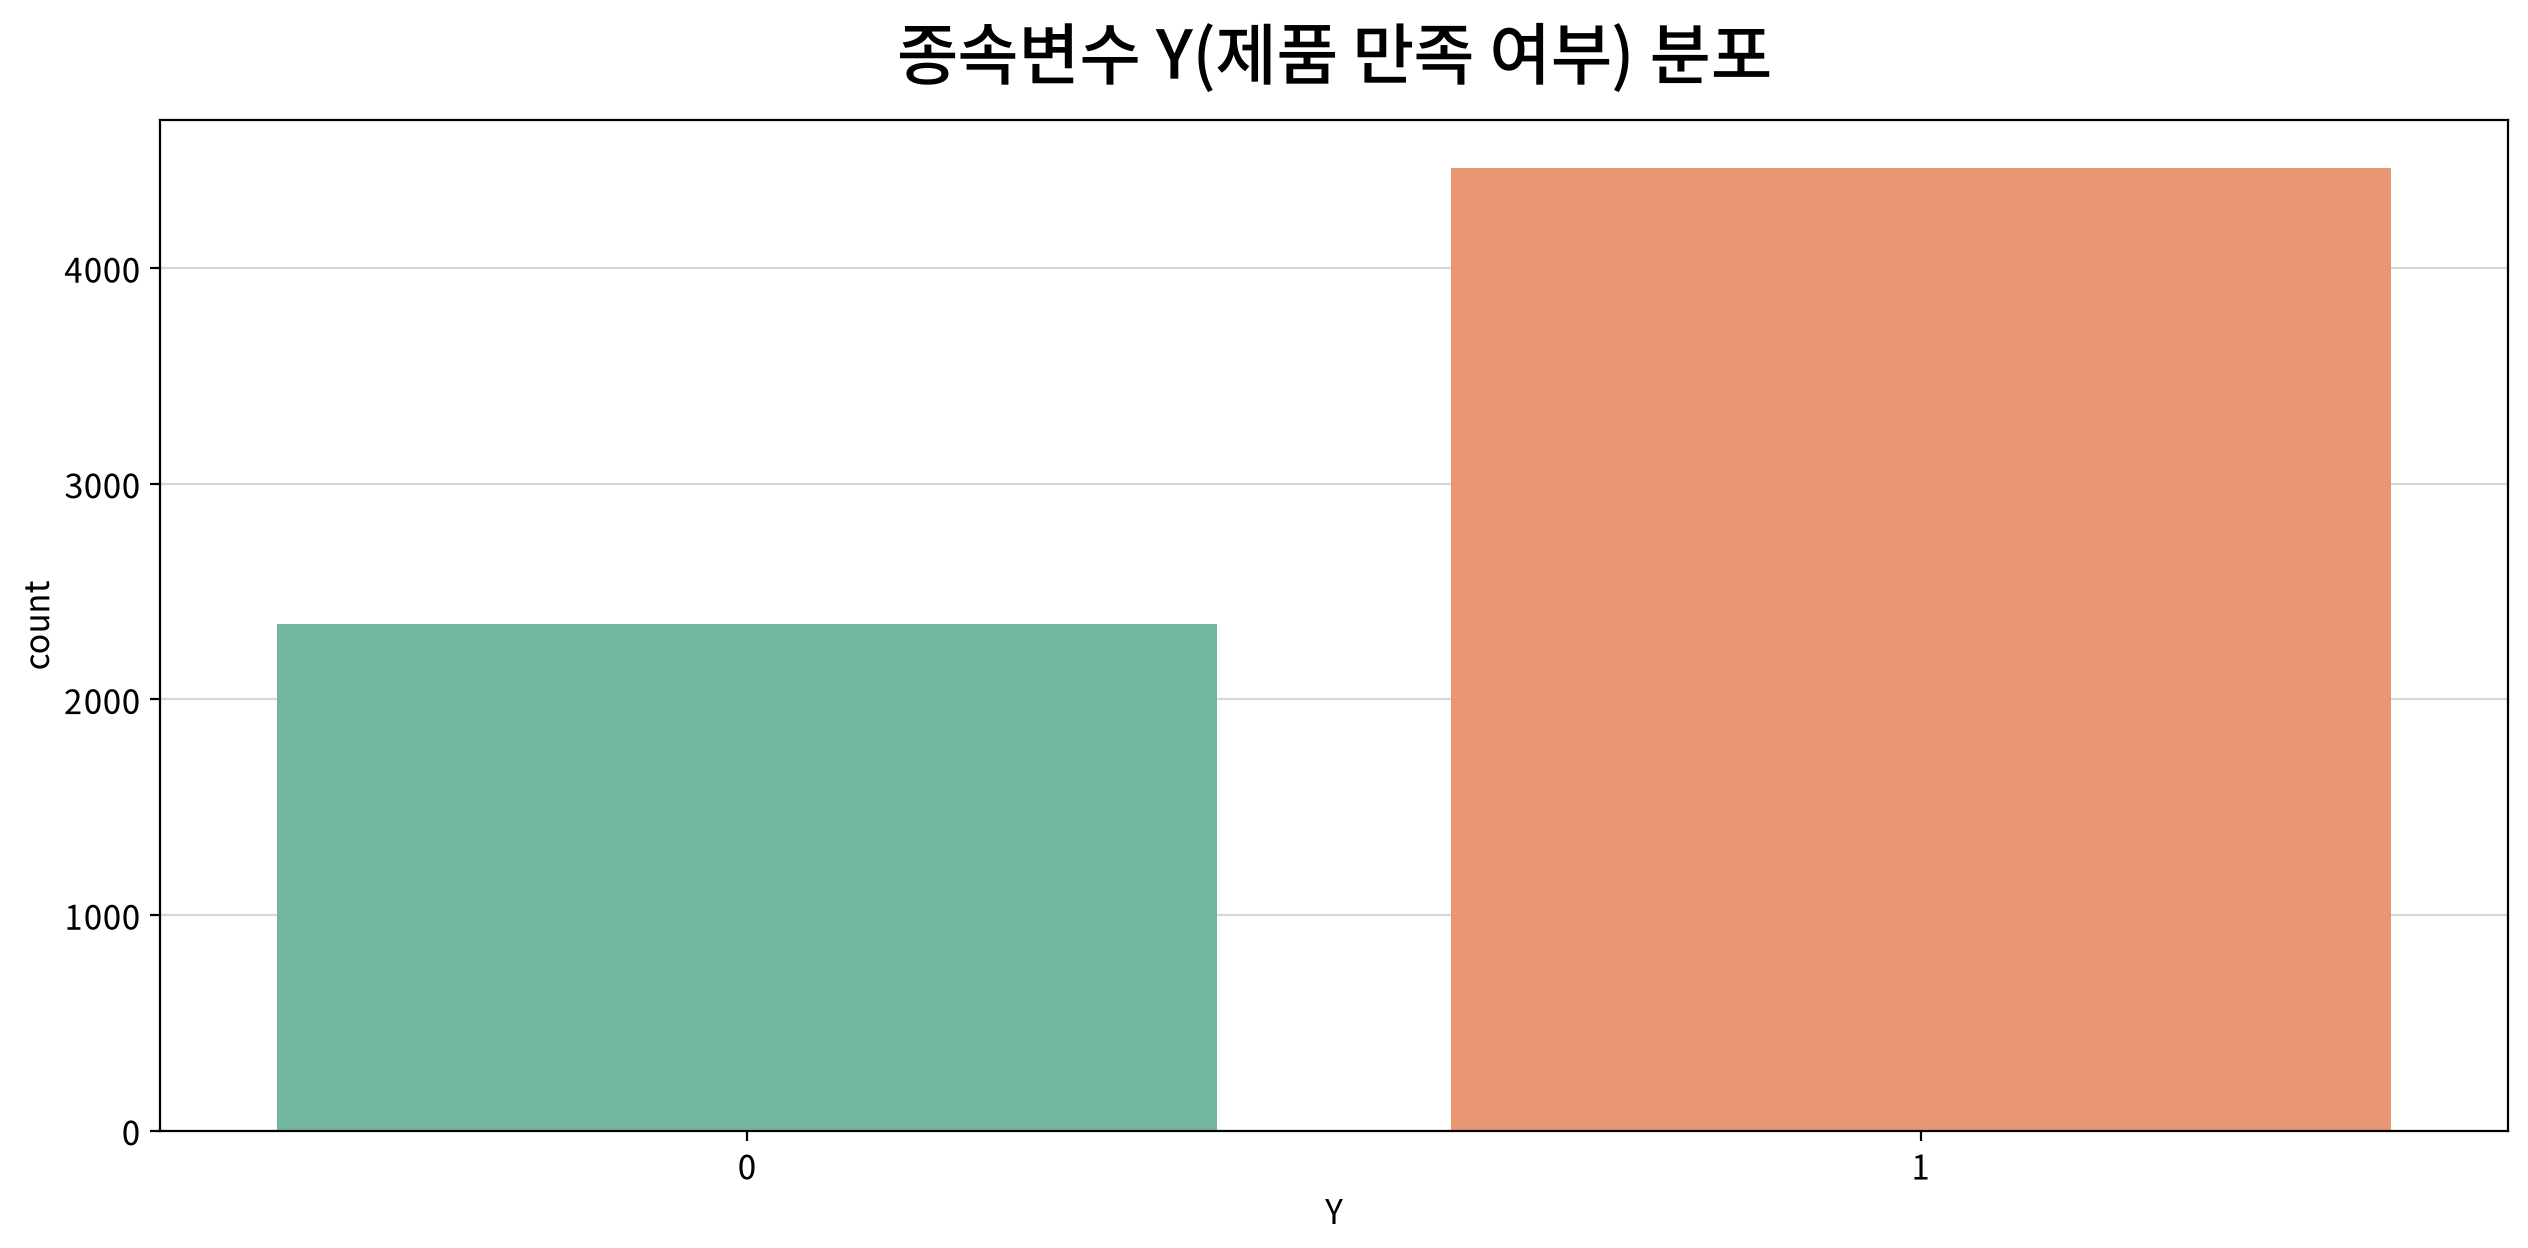

,빈도,비율
Y,,
1,4462,0.654924
0,2351,0.345076


In [16]:

my_plot.countplot(
    data=df_eda,
    x=target,
    hue=target,
    palette='Set2',
    title='종속변수 Y(제품 만족 여부) 분포'
)

freq = df_eda[target].value_counts().rename('빈도').to_frame()
freq['비율'] = df_eda[target].value_counts(normalize=True)

display(freq)

### 2. 명목형 독립변수 단변량 분석


In [17]:
column_means['국가'] = '리뷰 작성 국가'
column_means['제품_순위'] = '국가별 제품 순위'
column_means['Y'] = '제품 만족 여부'
column_means['보습'] = '보습 속성 언급 여부'
column_means['향'] = '향 속성 언급 여부'
column_means['발림성'] = '발림성 속성 언급 여부'
column_means['자극'] = '자극 속성 언급 여부'
column_means['용기'] = '용기 속성 언급 여부'
column_means['배송'] = '배송 속성 언급 여부'
column_means['기능'] = '기능 속성 언급 여부'
column_means['가격'] = '가격 속성 언급 여부'
column_means['브랜드충성도'] = '브랜드 충성도 언급 여부'
column_means['토픽_언급수'] = '한 리뷰에서 언급된 9개 속성의 개수'

### ▶︎ 국가 (리뷰 작성 국가) 분포

국가,한국,미국,러시아,일본
빈도,1850.00000,1832.000000,1627.000000,1504.000000
비율,0.27154,0.268898,0.238808,0.220754


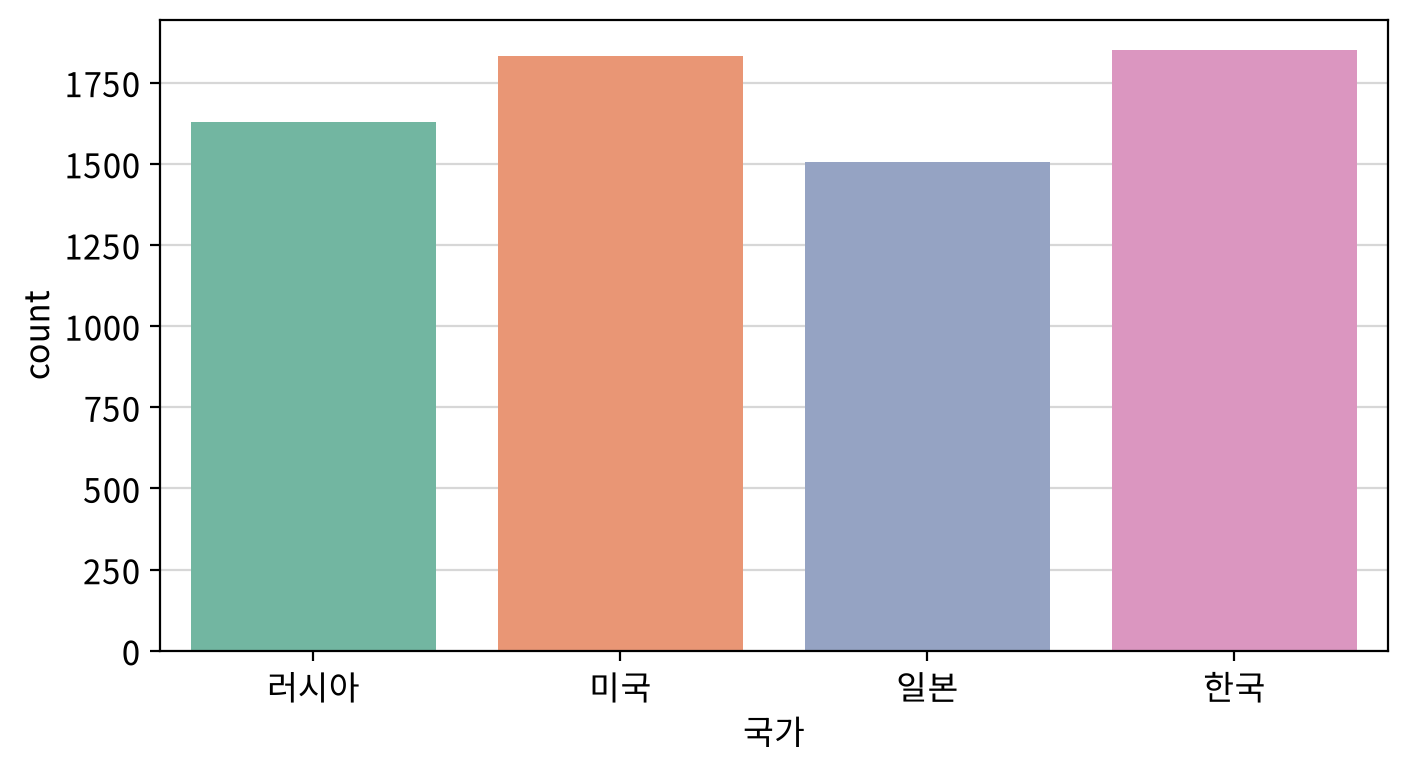

### ▶︎ 제품_순위 (국가별 제품 순위) 분포

제품_순위,8,9,2,1,10,3,5,4,7,6
빈도,747.000000,734.000000,688.000000,683.00000,683.00000,680.000000,663.000000,655.00000,647.000000,633.000000
비율,0.109643,0.107735,0.100983,0.10025,0.10025,0.099809,0.097314,0.09614,0.094966,0.092911


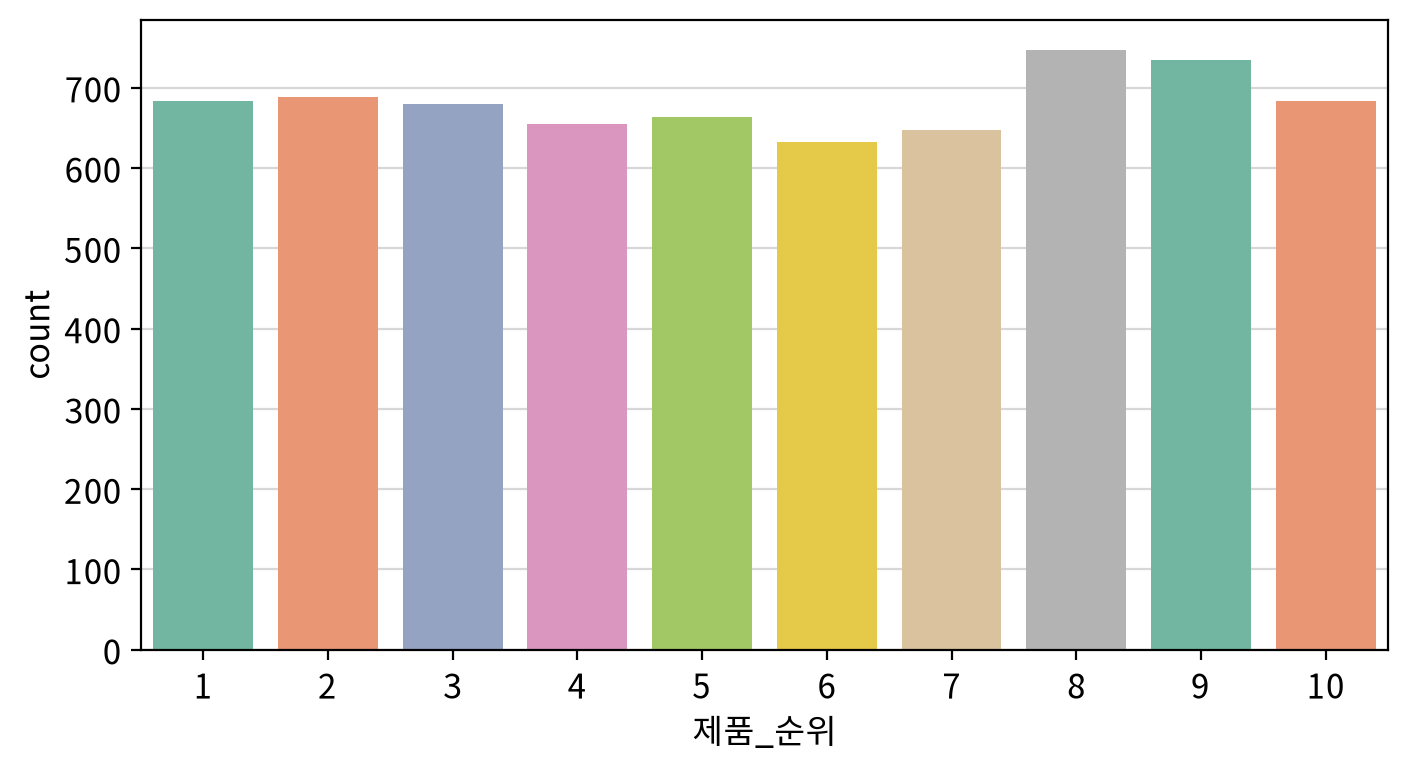

### ▶︎ 보습 (보습 속성 언급 여부) 분포

보습,0,1
빈도,3714.000000,3099.000000
비율,0.545134,0.454866


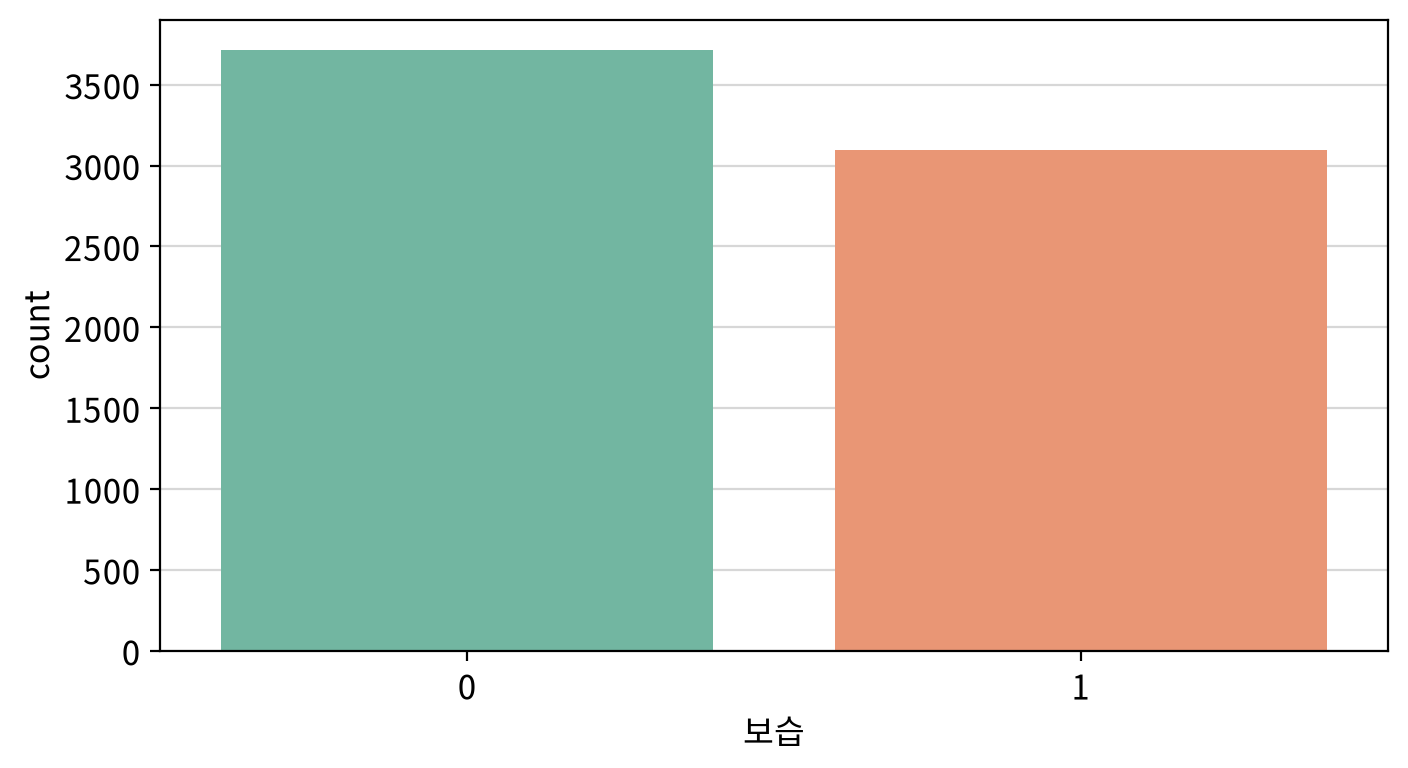

### ▶︎ 향 (향 속성 언급 여부) 분포

향,0,1
빈도,5714.000000,1099.000000
비율,0.838691,0.161309


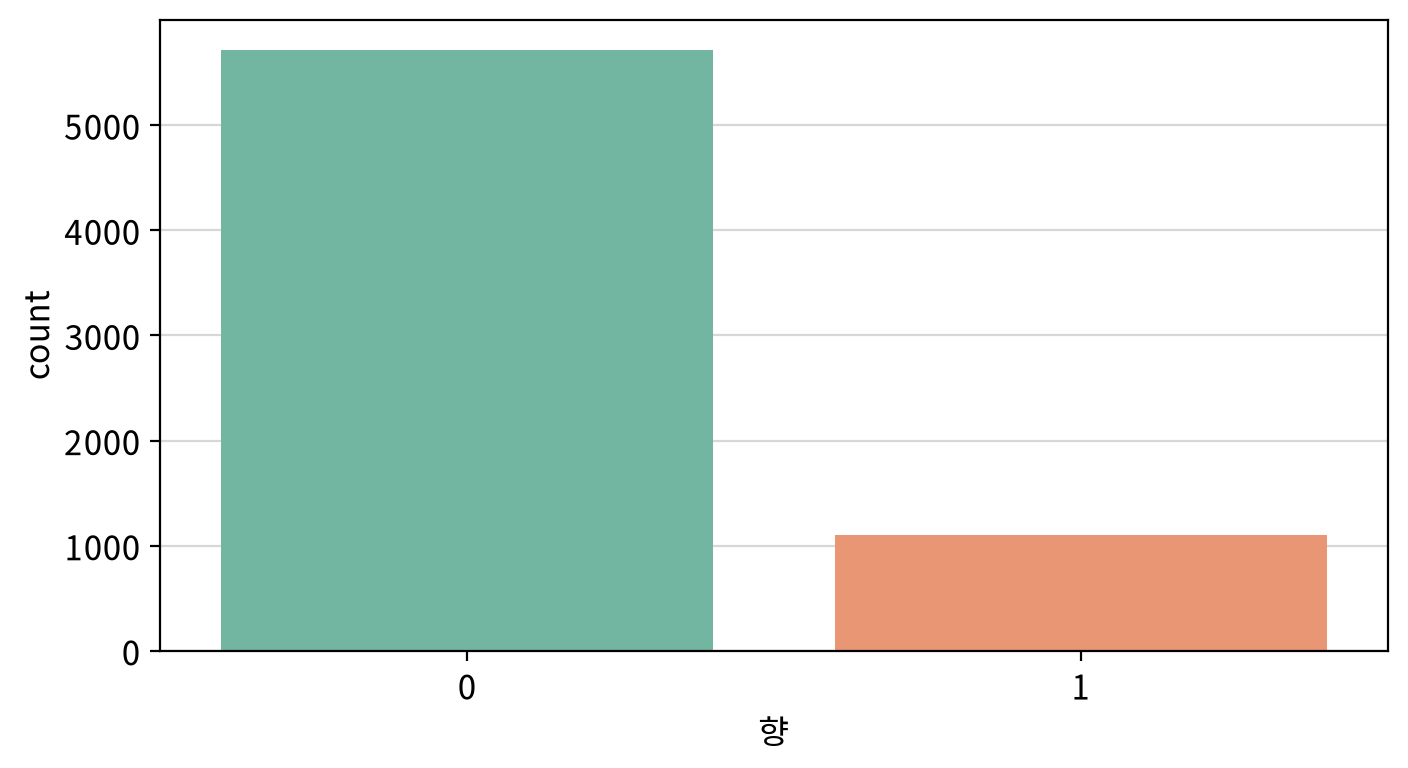

### ▶︎ 발림성 (발림성 속성 언급 여부) 분포

발림성,0,1
빈도,3660.000000,3153.000000
비율,0.537208,0.462792


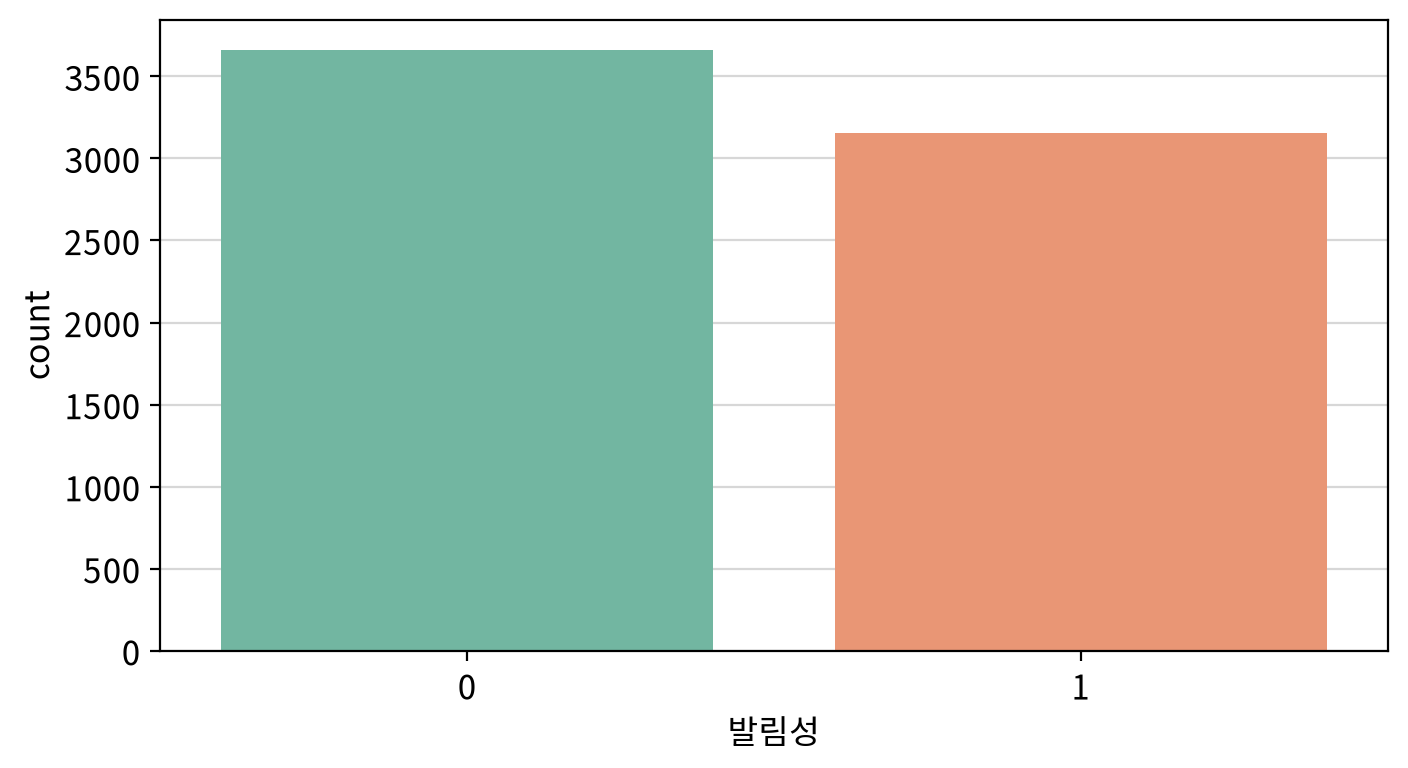

### ▶︎ 자극 (자극 속성 언급 여부) 분포

자극,0,1
빈도,3458.000000,3355.000000
비율,0.507559,0.492441


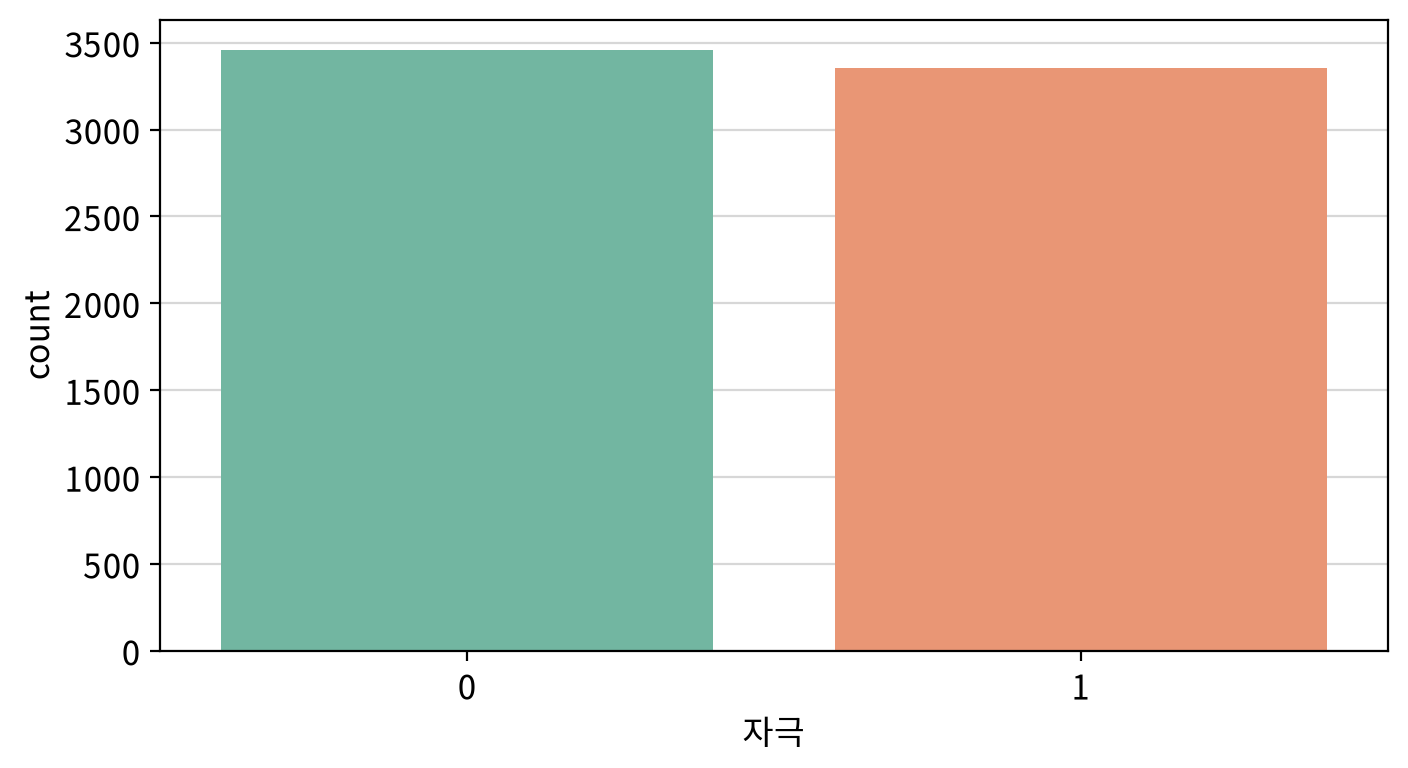

### ▶︎ 용기 (용기 속성 언급 여부) 분포

용기,0,1
빈도,5421.000000,1392.000000
비율,0.795685,0.204315


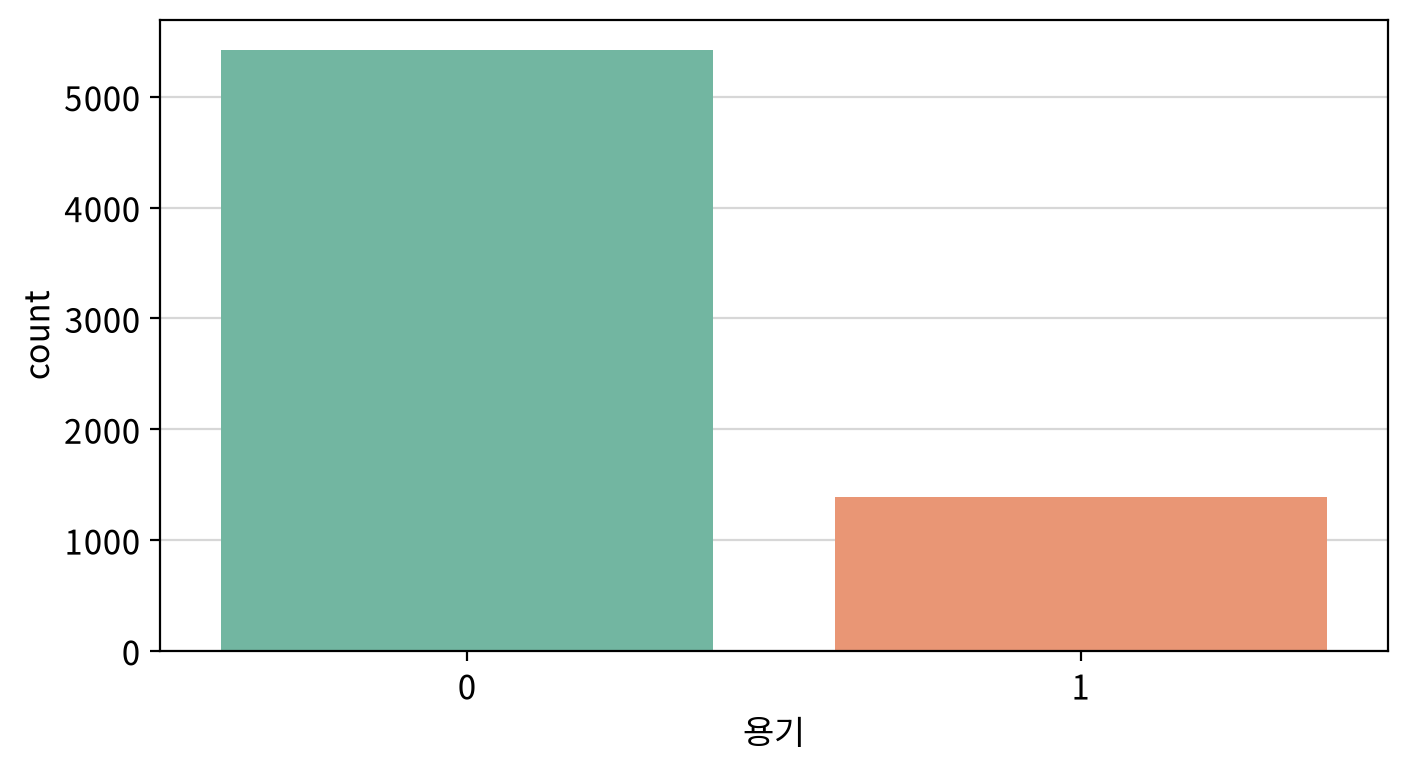

### ▶︎ 배송 (배송 속성 언급 여부) 분포

배송,0,1
빈도,6386.000000,427.000000
비율,0.937326,0.062674


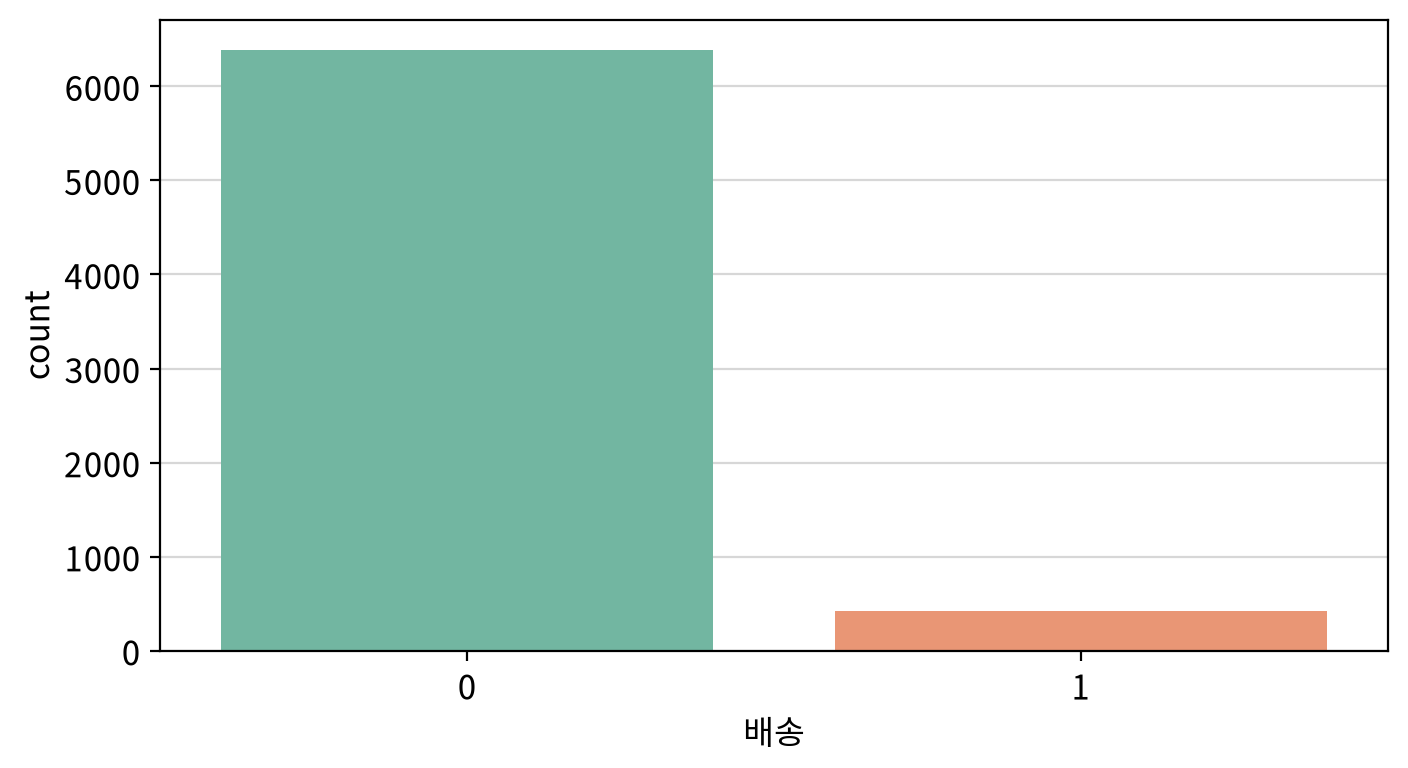

### ▶︎ 기능 (기능 속성 언급 여부) 분포

기능,0,1
빈도,3897.000000,2916.000000
비율,0.571995,0.428005


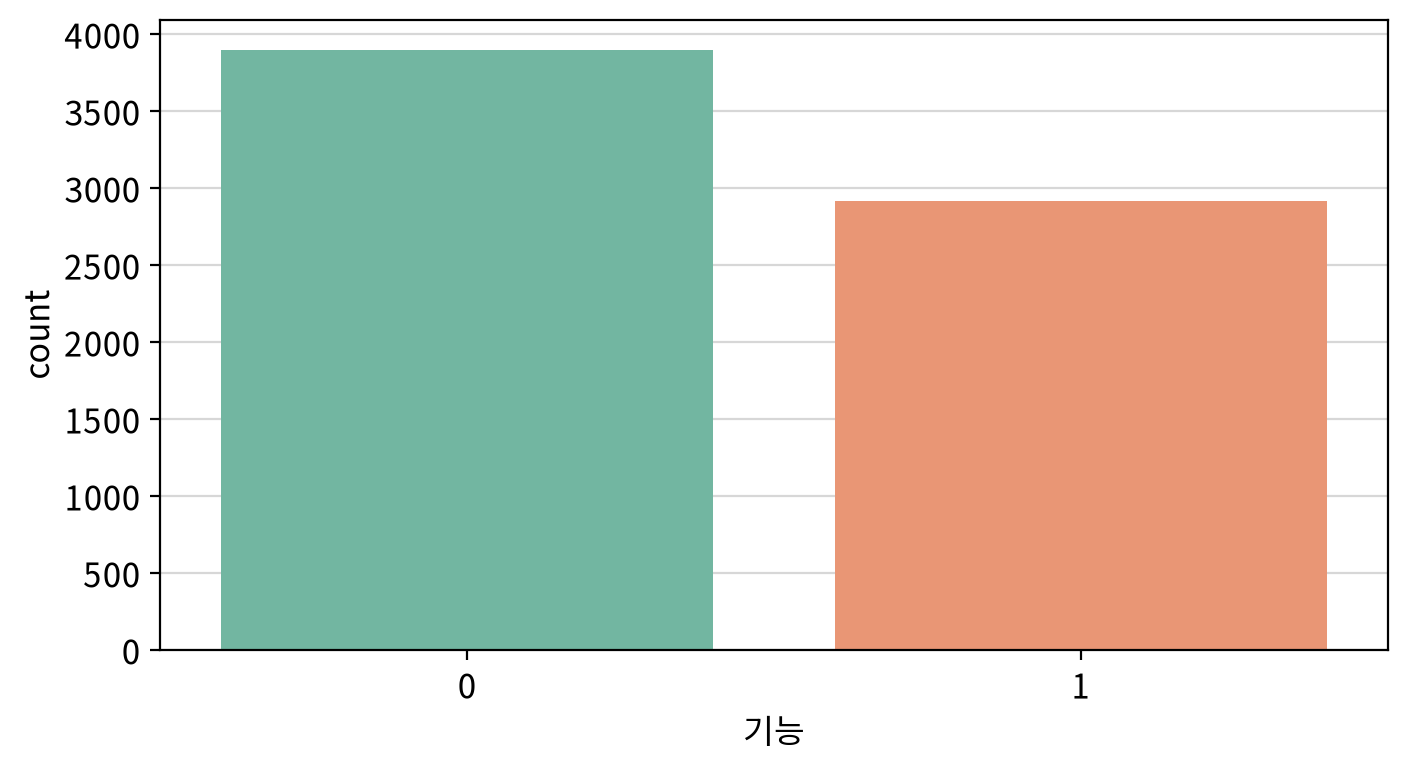

### ▶︎ 가격 (가격 속성 언급 여부) 분포

가격,0,1
빈도,6265.000000,548.000000
비율,0.919566,0.080434


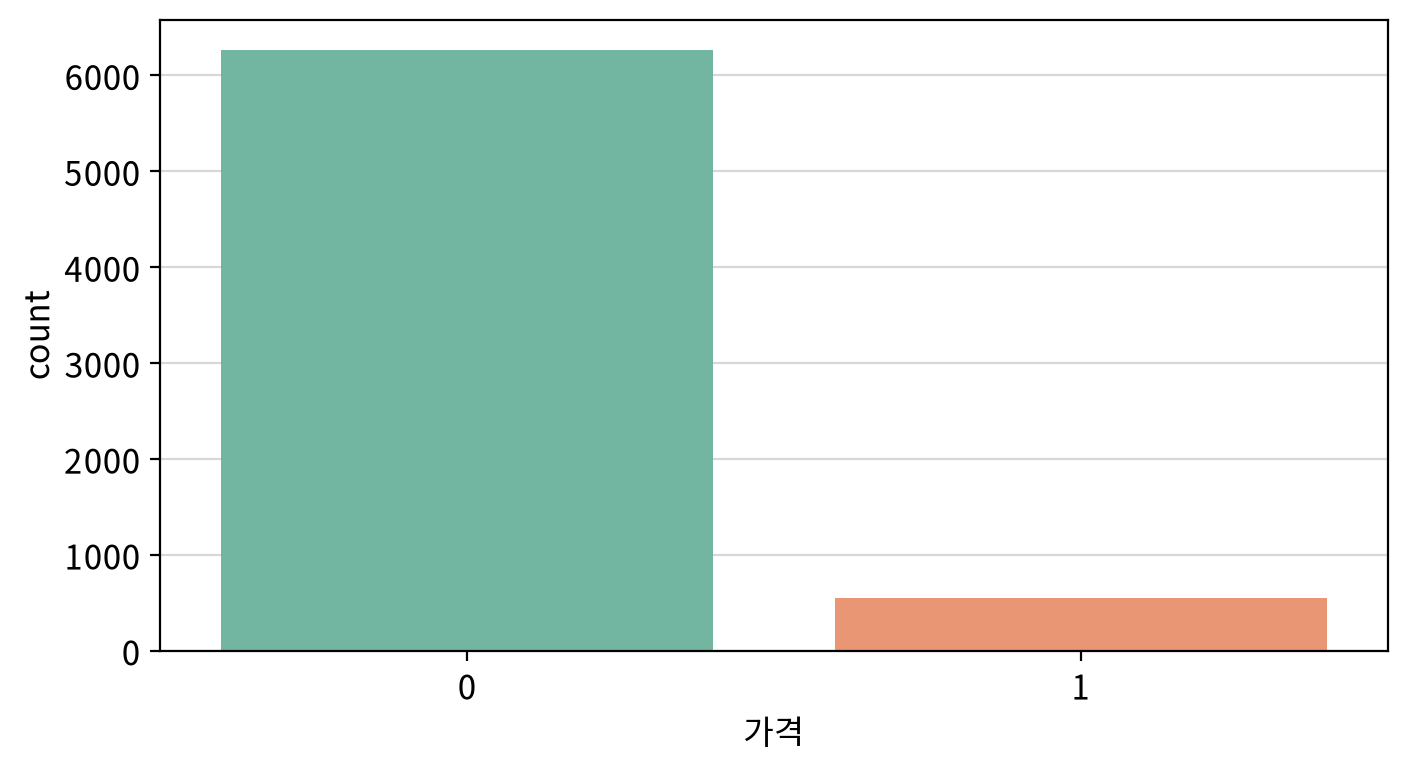

### ▶︎ 브랜드충성도 (브랜드 충성도 언급 여부) 분포

브랜드충성도,0,1
빈도,5892.000000,921.000000
비율,0.864817,0.135183


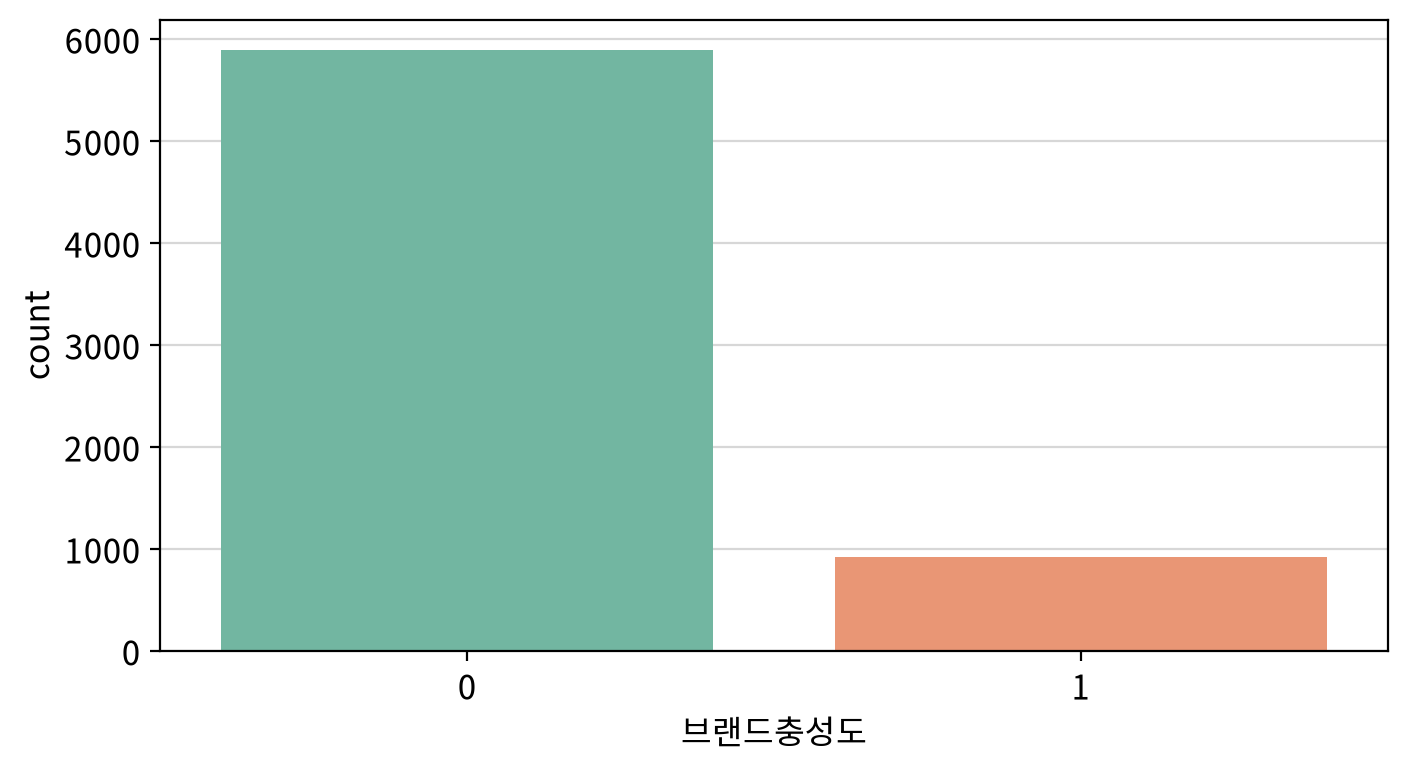

In [18]:
for n in nominal_cols:
    display(Markdown(f"### ▶︎ {n} ({column_means[n]}) 분포"))

    freq = df_eda[n].value_counts().rename('빈도').to_frame()
    freq['비율'] = df_eda[n].value_counts(normalize=True)

    display(freq.T)

    my_plot.countplot(
        data=df_eda,
        x=n,
        hue=n,
        palette='Set2',
        width=720,
        height=400
    )

## 2. 명목형 독립변수 단변량 분석

### 1) 국가

- 한국 1,850건(27.15%), 미국 1,832건(26.89%), 러시아 1,627건(23.88%), 일본 1,504건(22.08%)으로 구성되어 있다.
- 한국과 미국의 비중이 상대적으로 높지만, 특정 국가에 데이터가 과도하게 집중되어 있지는 않다.
- 따라서 국가별 비교 분석을 수행하기에 비교적 균형적인 분포를 보인다.

### 2) 제품_순위

- 제품 순위 1~10위의 비중은 각각 약 9~11% 수준으로 나타났다.
- 가장 많은 8위 제품은 747건(10.96%), 가장 적은 6위 제품은 633건(9.29%)으로 확인되었다.
- 제품 순위별 표본 수 차이가 크지 않아 전반적으로 고른 분포를 보인다.
- `제품_순위`는 숫자로 표현되어 있으나 순위 간 간격을 수치적으로 동일하다고 가정하지 않고 범주형 변수로 분석한다.

### 3) 보습

- 보습 속성이 언급되지 않은 리뷰(`0`)는 3,714건(54.51%), 언급된 리뷰(`1`)는 3,099건(45.49%)으로 나타났다.
- 보습 미언급 리뷰의 비율이 약간 높지만, 0과 1이 크게 치우치지 않고 비교적 균형적인 분포를 보인다.
- 따라서 이후 `Y`와의 교차분석을 통해 보습 속성 언급 여부에 따른 만족 여부의 차이를 확인한다.

## #08. 이변량 분석
### 1. 명목형 독립변수 → Y 교차분석

#### ▶︎ 국가 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
국가,Y,Chi-square test of independence,671.1319,3,0.0,True,0.3139,Moderate,518.99,True


Y,0,1
국가,,
러시아,0.166564,0.833436
미국,0.466703,0.533297
일본,0.203457,0.796543
한국,0.496757,0.503243


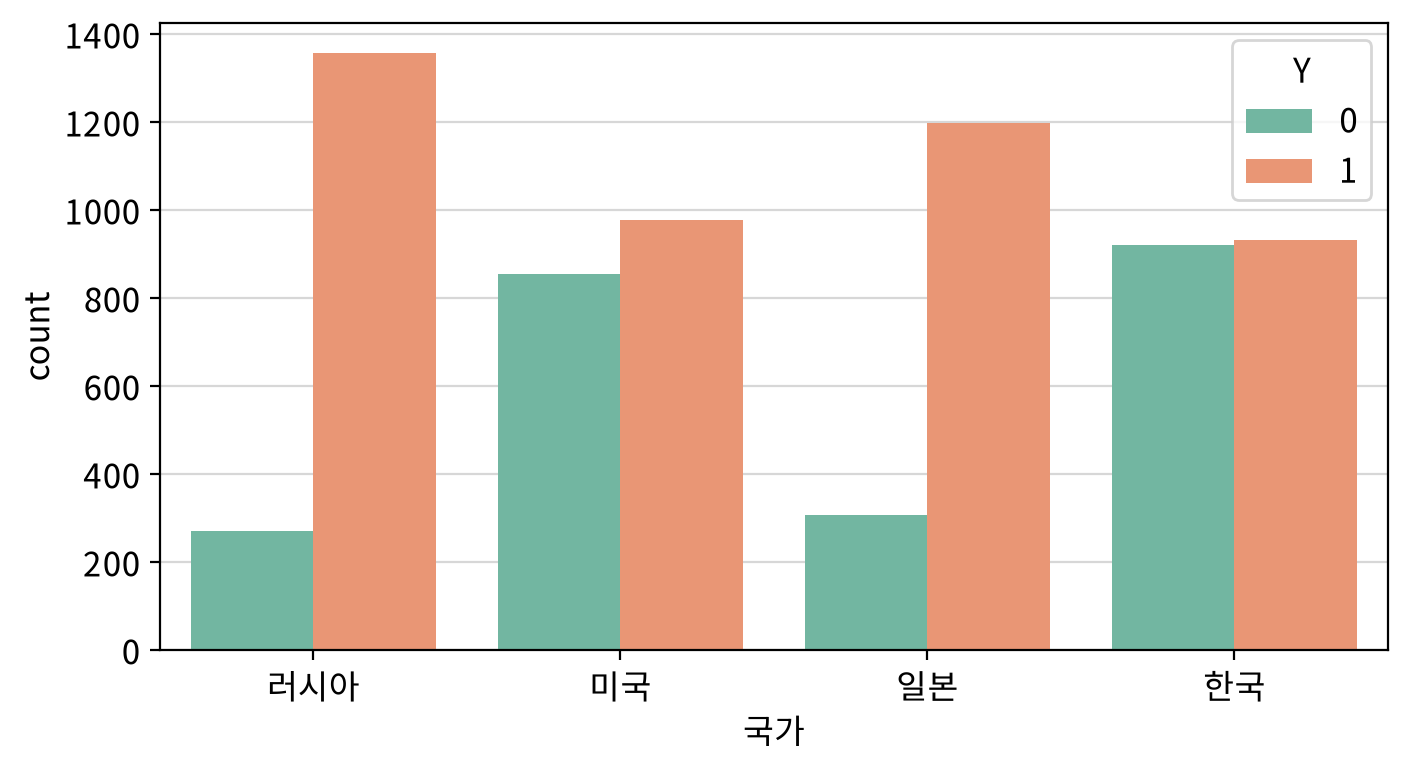

#### ▶︎ 제품_순위 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
제품_순위,Y,Chi-square test of independence,64.8945,9,0.0,True,0.0976,Negligible,218.43,True


Y,0,1
제품_순위,,
1,0.355783,0.644217
2,0.341570,0.658430
3,0.327941,0.672059
4,0.334351,0.665649
5,0.369532,0.630468
6,0.306477,0.693523
7,0.234930,0.765070
8,0.419009,0.580991
9,0.374659,0.625341


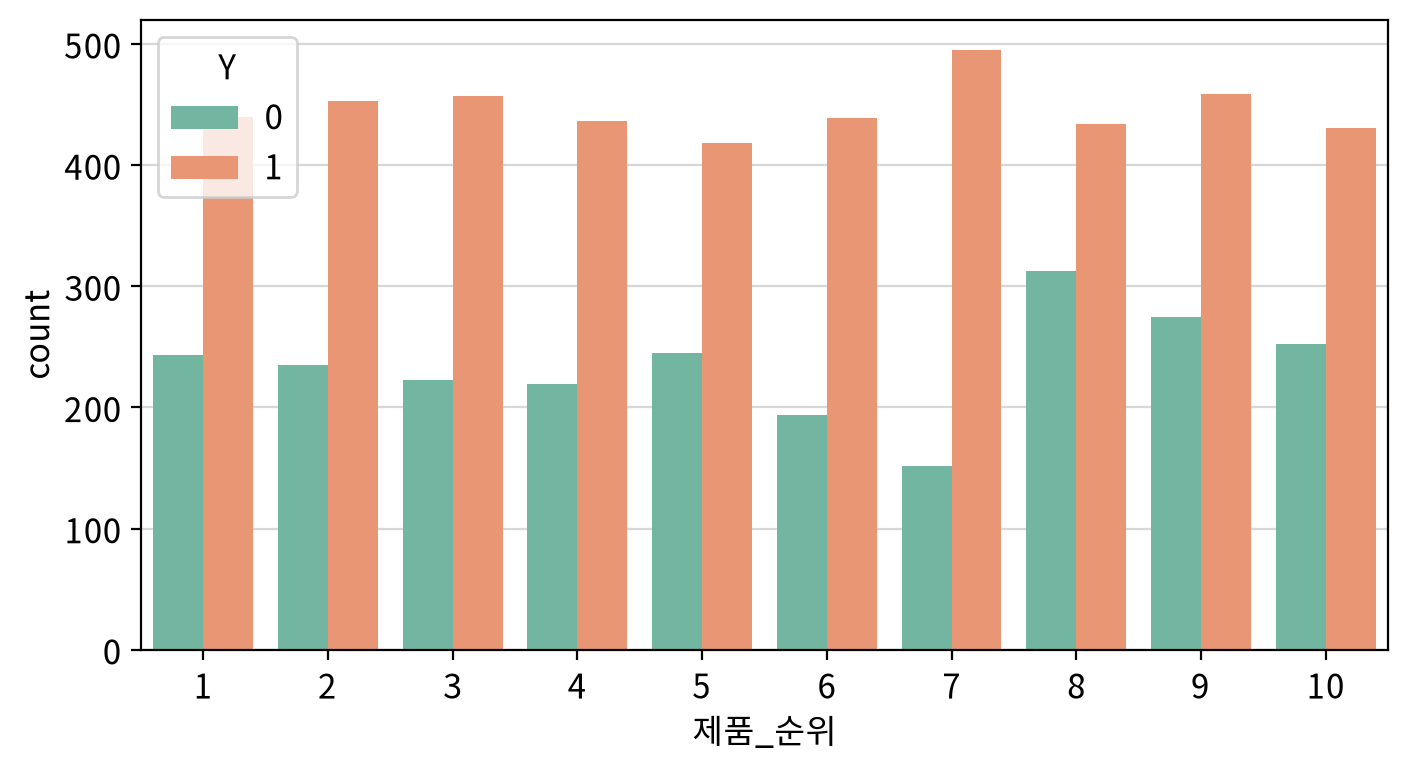

#### ▶︎ 보습 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
보습,Y,Chi-square test of independence,66.9589,1,0.0,True,0.0991,Negligible,1069.39,True


Y,0,1
보습,,
0,0.388261,0.611739
1,0.293320,0.706680


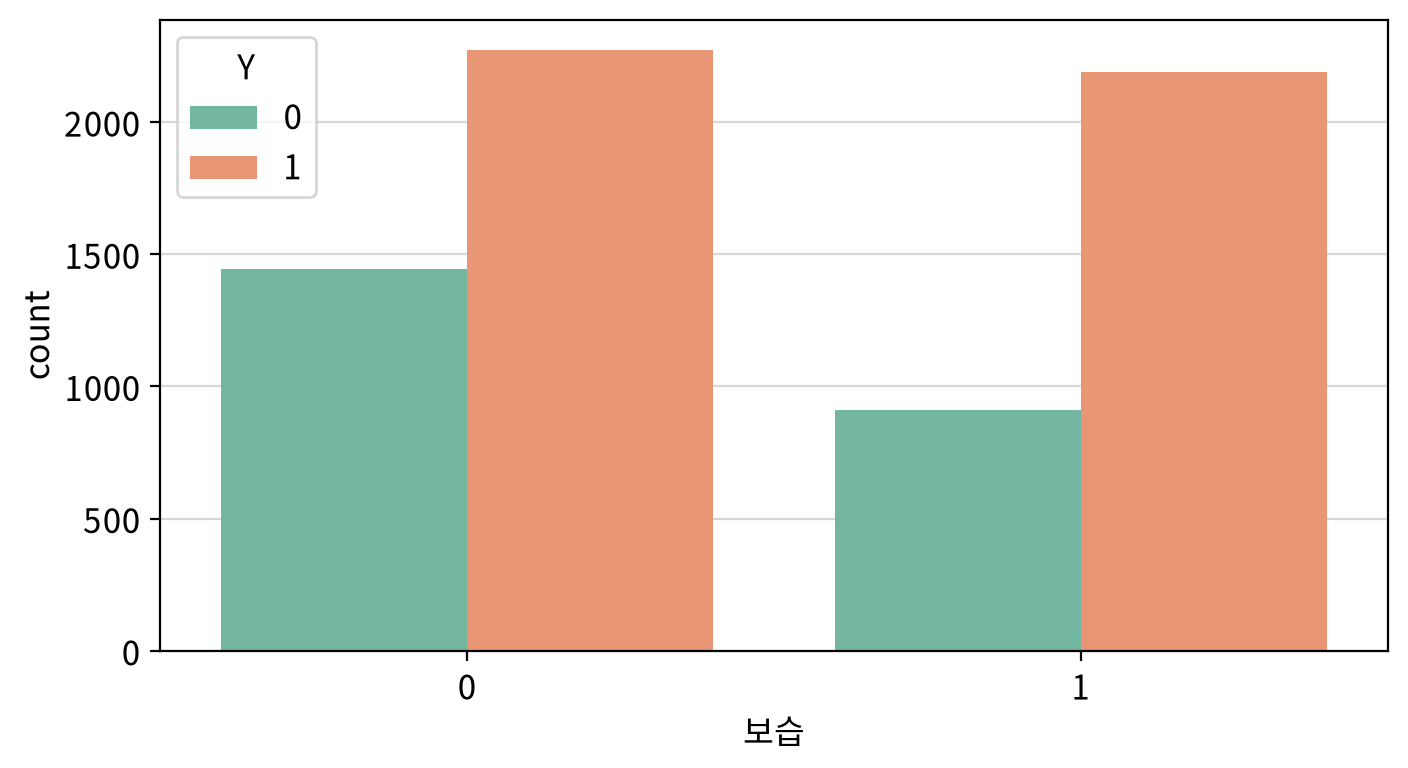

#### ▶︎ 향 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
향,Y,Chi-square test of independence,100.5682,1,0.0,True,0.1215,Weak,379.24,True


Y,0,1
향,,
0,0.370494,0.629506
1,0.212921,0.787079


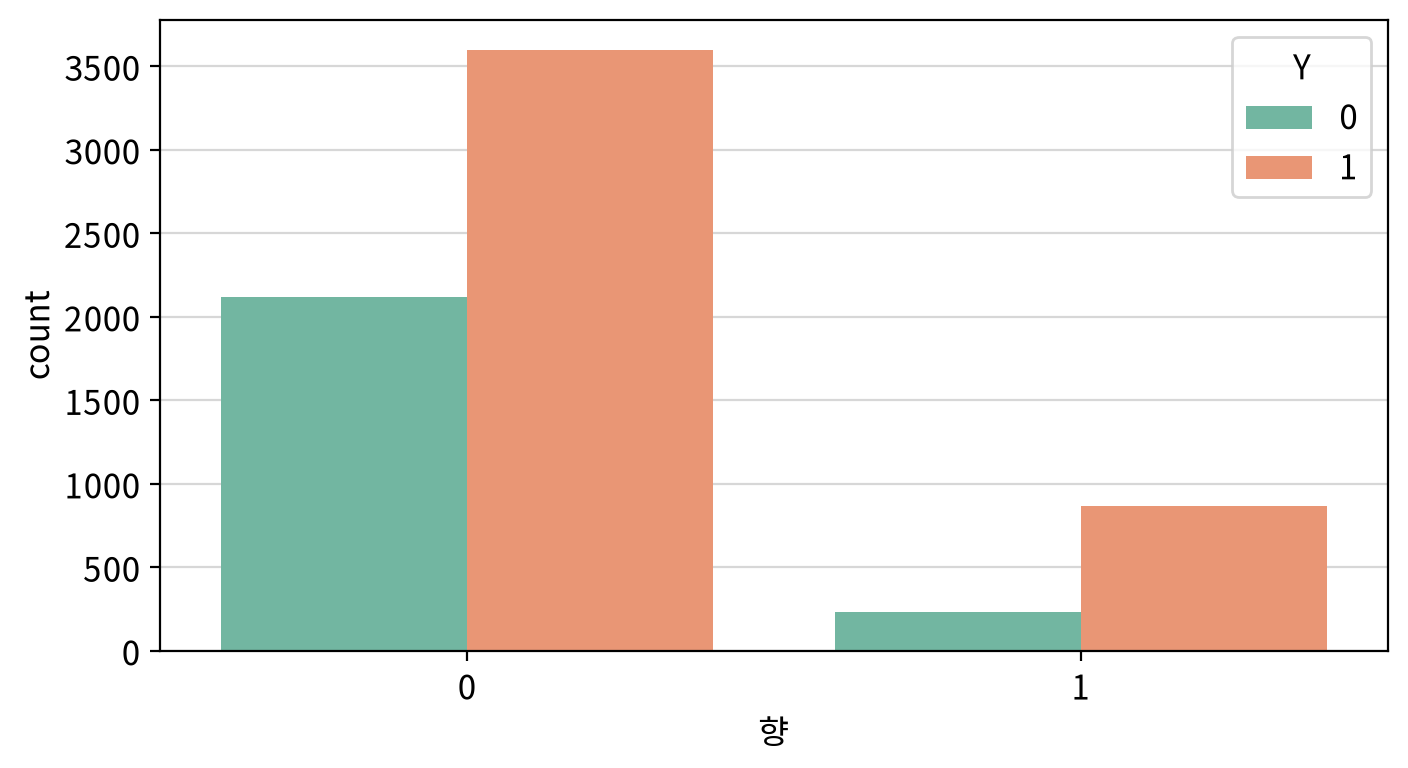

#### ▶︎ 발림성 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
발림성,Y,Chi-square test of independence,39.2162,1,0.0,True,0.0759,Negligible,1088.02,True


Y,0,1
발림성,,
0,0.378689,0.621311
1,0.306058,0.693942


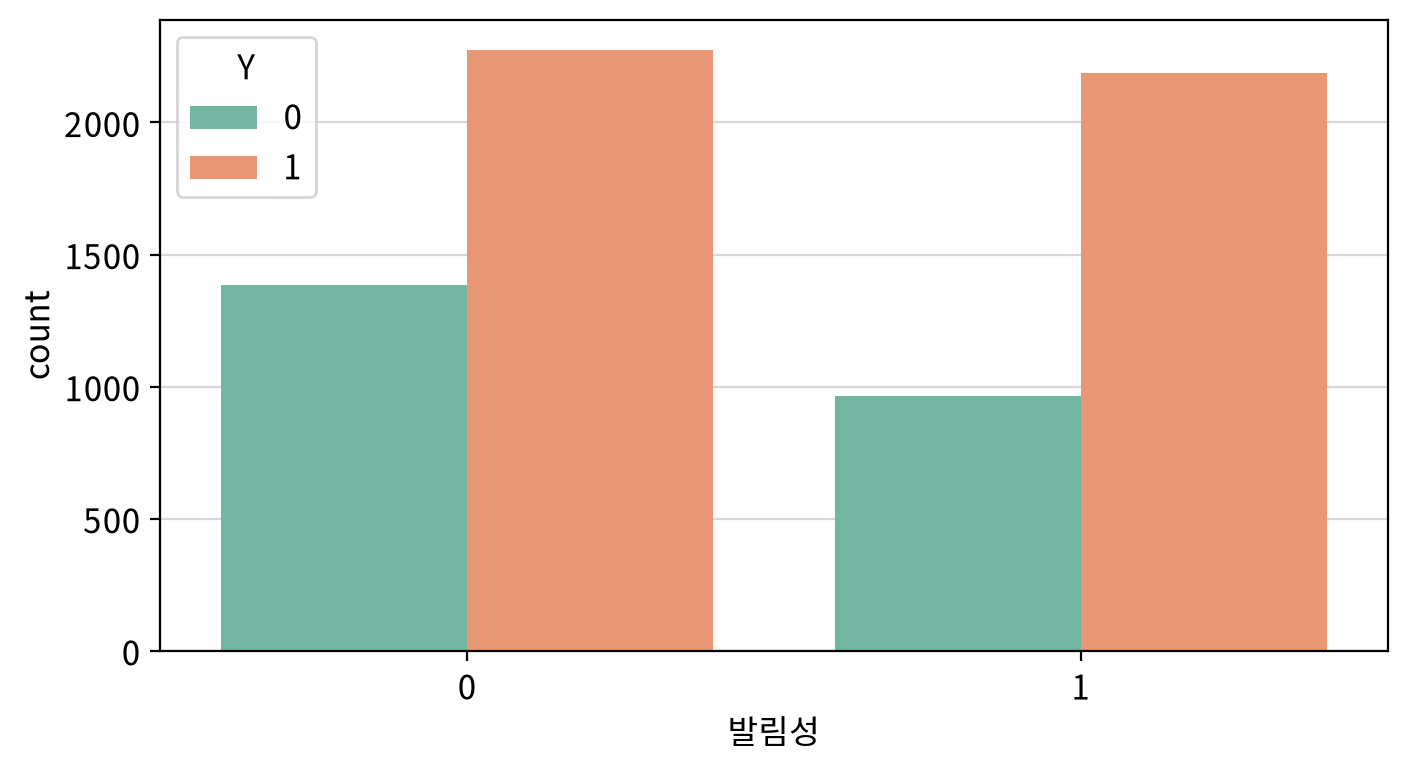

#### ▶︎ 자극 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
자극,Y,Chi-square test of independence,754.266,1,0.0,True,0.3327,Moderate,1157.73,True


Y,0,1
자극,,
0,0.189127,0.810873
1,0.505812,0.494188


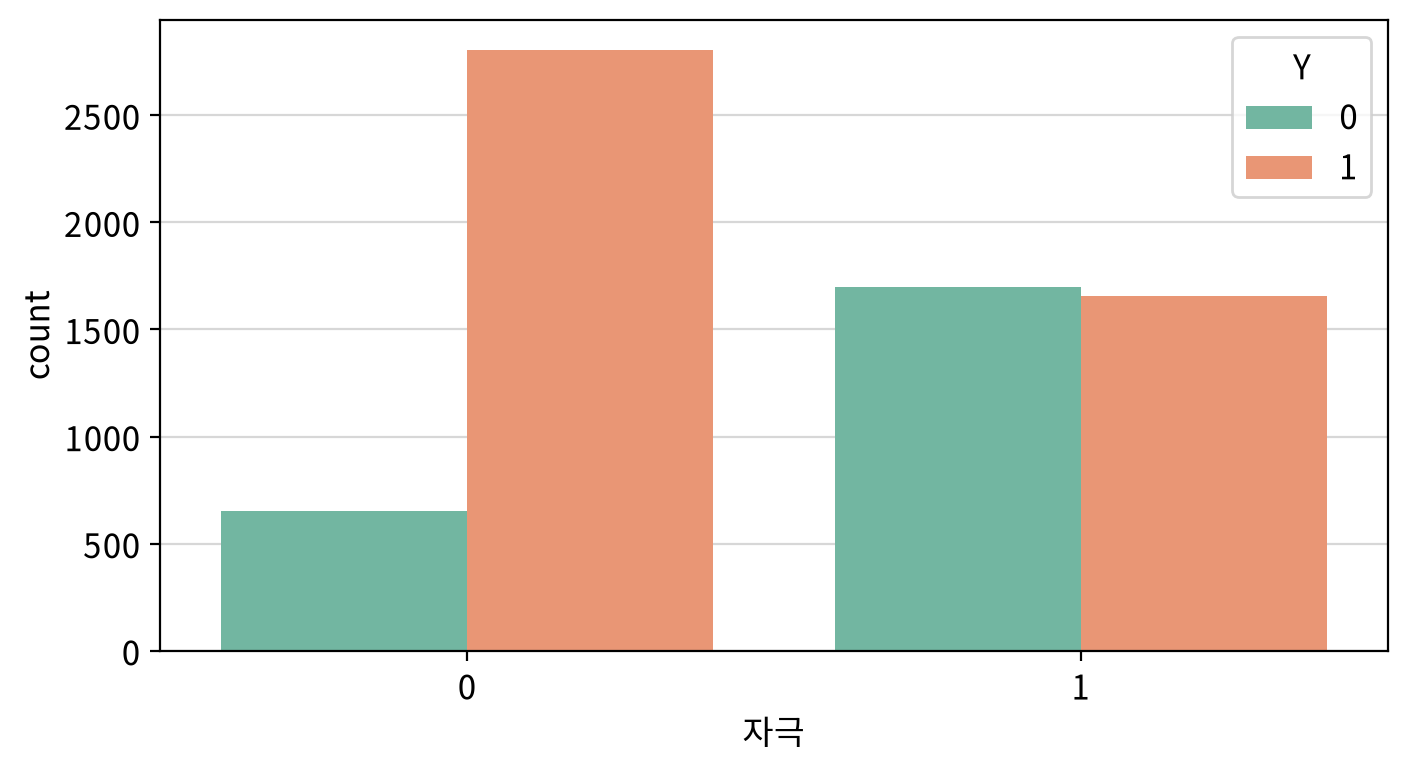

#### ▶︎ 용기 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
용기,Y,Chi-square test of independence,18.3888,1,0.000018,True,0.052,Negligible,480.35,True


Y,0,1
용기,,
0,0.357683,0.642317
1,0.295977,0.704023


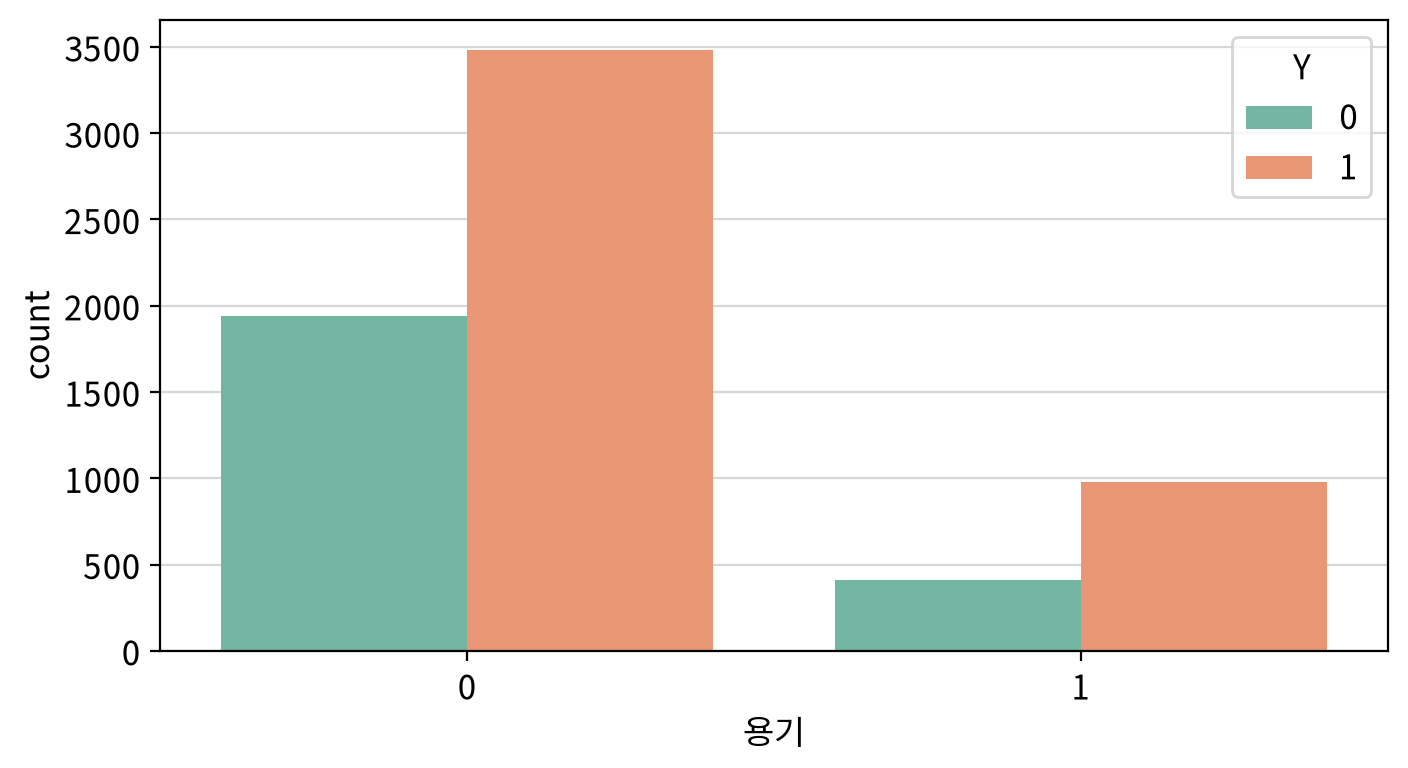

#### ▶︎ 배송 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
배송,Y,Chi-square test of independence,49.8544,1,0.0,True,0.0855,Negligible,147.35,True


Y,0,1
배송,,
0,0.334482,0.665518
1,0.503513,0.496487


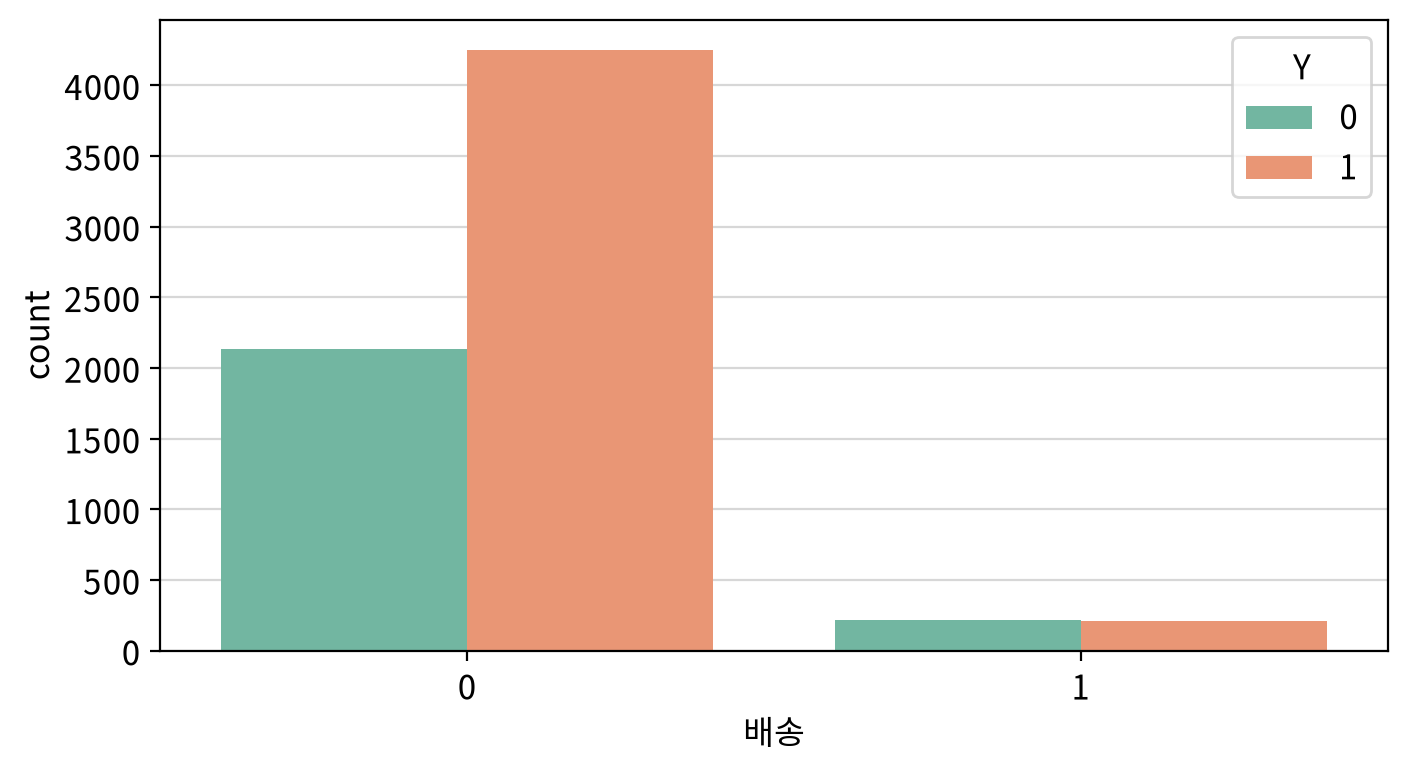

#### ▶︎ 기능 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
기능,Y,Chi-square test of independence,72.8739,1,0.0,True,0.1034,Weak,1006.24,True


Y,0,1
기능,,
0,0.387734,0.612266
1,0.288066,0.711934


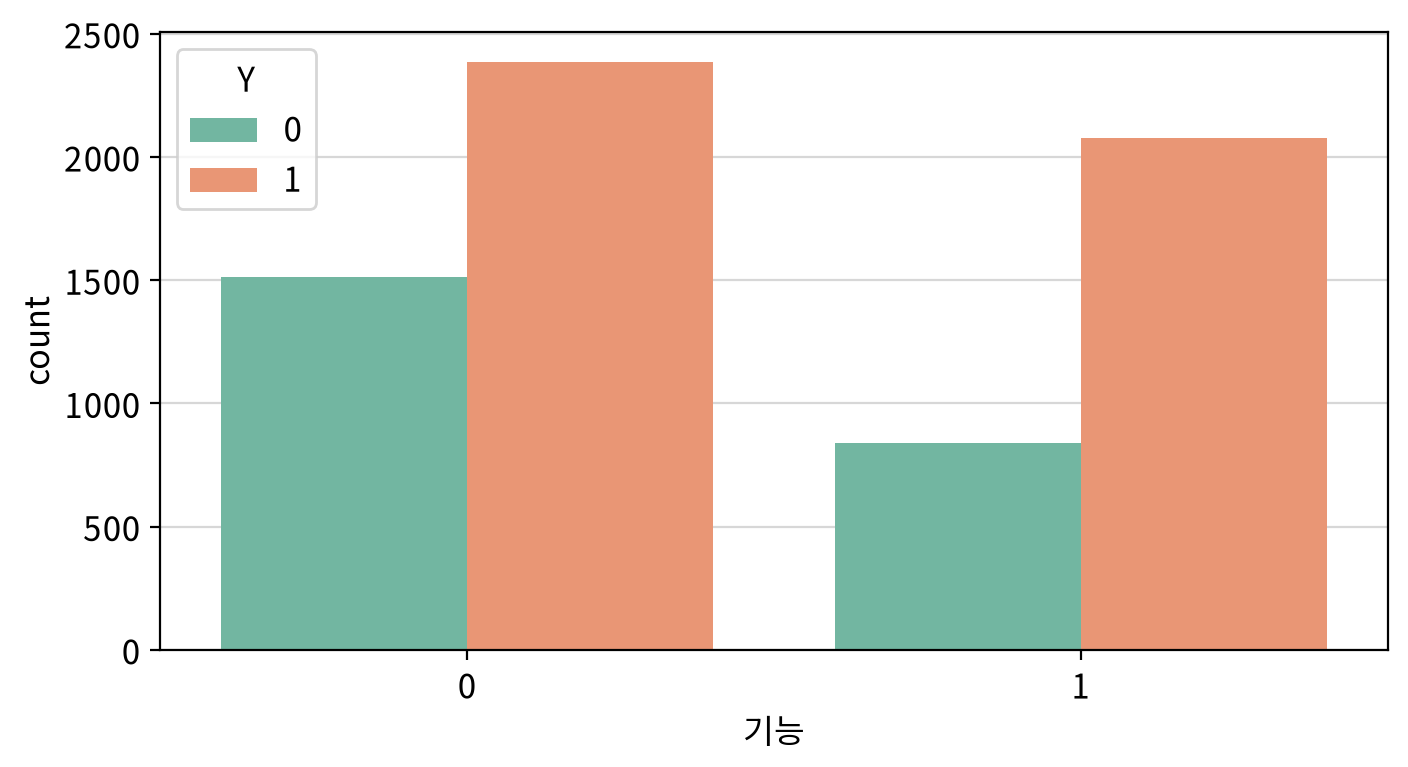

#### ▶︎ 가격 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
가격,Y,Chi-square test of independence,13.0839,1,0.000298,True,0.0438,Negligible,189.1,True


Y,0,1
가격,,
0,0.351317,0.648683
1,0.273723,0.726277


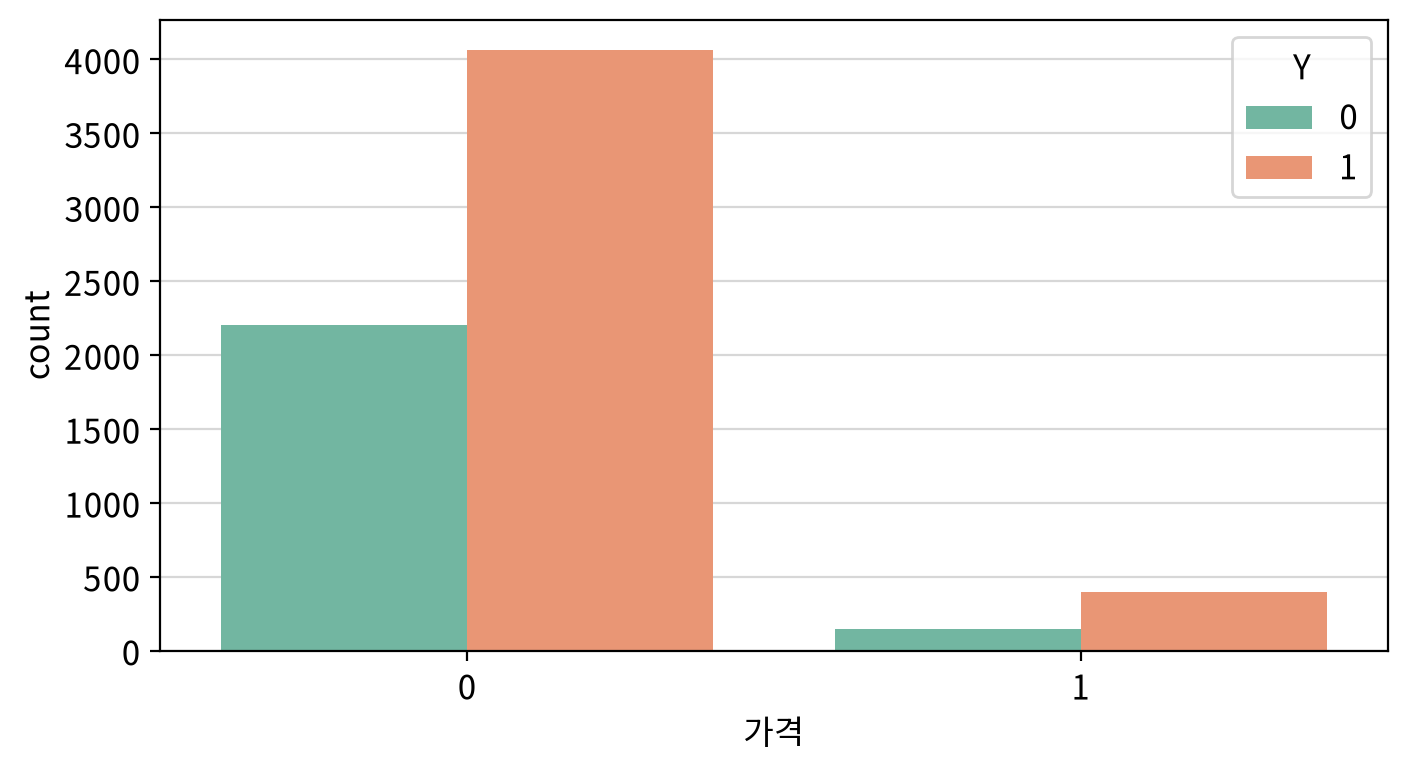

#### ▶︎ 브랜드충성도 → Y

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
브랜드충성도,Y,Chi-square test of independence,9.0289,1,0.002657,True,0.0364,Negligible,317.81,True


Y,0,1
브랜드충성도,,
0,0.352003,0.647997
1,0.300760,0.699240


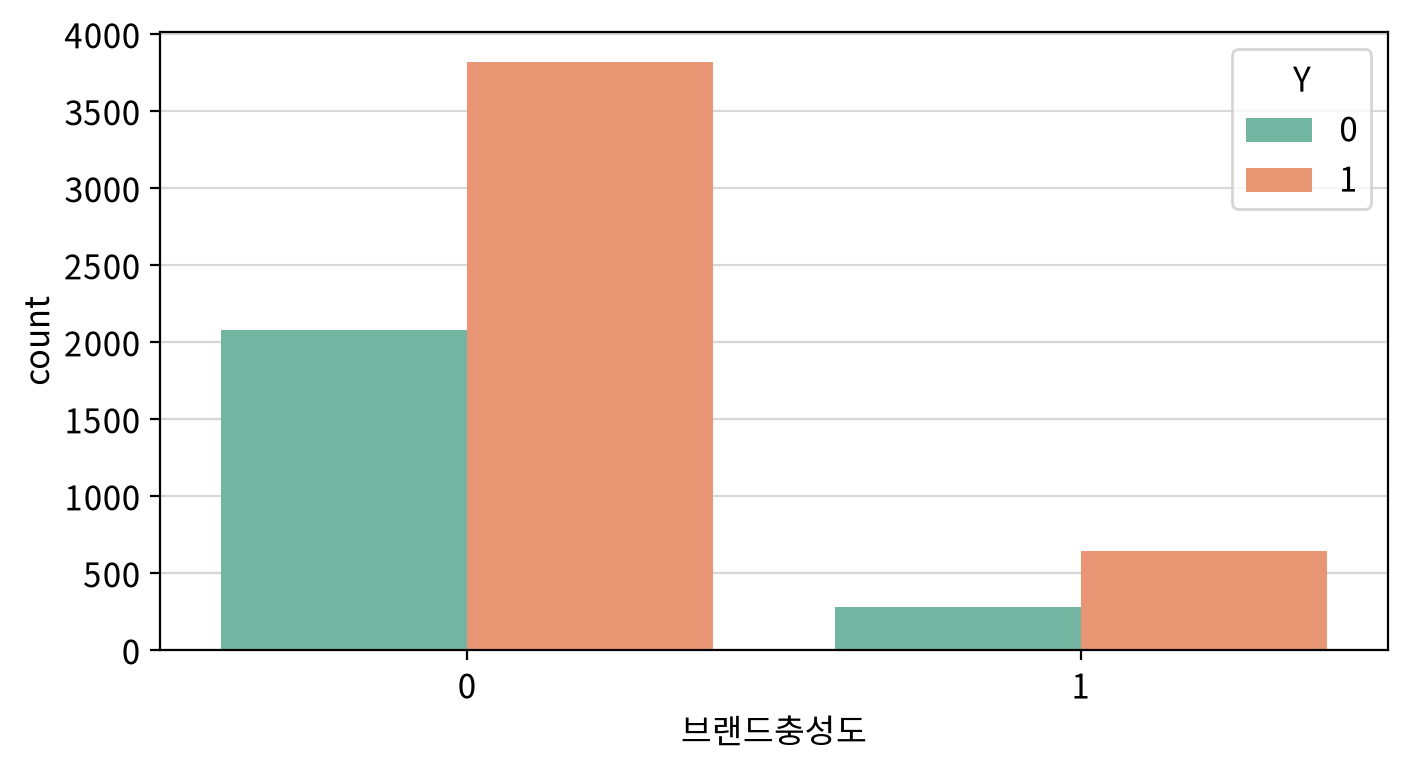

In [19]:

for n in nominal_cols:

    print()
    display(Markdown(f"#### ▶︎ {n} → {target}"))

    # 카이제곱 독립성 검정
    display(
        my_stats.chi2_independence(
            df_eda,
            x=n,
            y=target,
            plot=False
        )
    )

    # 범주별 Y 비율
    rate = (
        df_eda
        .groupby(n, observed=True)[target]
        .value_counts(normalize=True)
        .unstack()
    )

    display(rate)

    my_plot.countplot(
        data=df_eda,
        x=n,
        hue=target,
        palette='Set2',
        width=720,
        height=400
    )

### 2. 국가별 속성 언급 패턴


In [20]:

for topic in topic_cols:

    display(Markdown(f"#### ▶︎ 국가 → {topic}"))

    # 국가와 해당 속성 간 독립성 검정
    display(
        my_stats.chi2_independence(
            df_eda,
            x='국가',
            y=topic,
            plot=False
        )
    )

    # 국가별 0/1 비율
    rate = pd.crosstab(
        df_eda['국가'],
        df_eda[topic],
        normalize='index'
    ) * 100

    display(rate.round(2))

#### ▶︎ 국가 → 보습

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
국가,보습,Chi-square test of independence,471.637,3,0.0,True,0.2631,Weak,684.12,True


보습,0,1
국가,,
러시아,76.34,23.66
미국,43.40,56.60
일본,56.05,43.95
한국,45.08,54.92


#### ▶︎ 국가 → 향

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
국가,향,Chi-square test of independence,910.8977,3,0.0,True,0.3657,Moderate,242.61,True


...

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
국가,가격,Chi-square test of independence,70.1443,3,0.0,True,0.1015,Weak,120.97,True


가격,0,1
국가,,
러시아,95.33,4.67
미국,92.90,7.10
일본,87.37,12.63
한국,91.78,8.22


#### ▶︎ 국가 → 브랜드충성도

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
국가,브랜드충성도,Chi-square test of independence,278.9823,3,0.0,True,0.2024,Weak,203.31,True


브랜드충성도,0,1
국가,,
러시아,91.09,8.91
미국,89.30,10.70
일본,73.54,26.46
한국,90.16,9.84


# 08. 이변량 분석

## 1. 명목형 독립변수와 Y의 관계

종속변수 `Y`와 각 명목형 독립변수 간의 관계를 확인하기 위해 교차분석과 카이제곱 독립성 검정을 수행하였다.

분석 대상 변수는 다음과 같다.

- 국가
- 제품_순위
- 보습
- 향
- 발림성
- 자극
- 용기
- 배송
- 기능
- 가격
- 브랜드충성도

각 변수의 범주별로 `Y=0`과 `Y=1`의 비율을 비교하고, 카이제곱 검정을 통해 두 변수 간 통계적으로 유의한 관련성이 존재하는지 확인하였다.

### 판단 기준

- `p-value < 0.05` : 해당 독립변수와 `Y` 사이에 통계적으로 유의한 관련성이 있다고 판단한다.
- `p-value ≥ 0.05` : 해당 독립변수와 `Y` 사이의 관련성이 통계적으로 유의하지 않다고 판단한다.

또한 단순히 유의확률만 확인하지 않고, 각 범주에서 `Y=0`과 `Y=1`의 비율이 실제로 어떻게 달라지는지도 함께 확인한다.

이 분석 결과를 바탕으로 이후 다변량 분석 및 최종 변수 선택에 활용한다.

## #09. 다변량 분석
### 1. 속성간 상관관계 확인


In [21]:

topic_corr = df_derived[topic_cols].corr(method='pearson')

display(topic_corr)

,보습,향,발림성,자극,용기,배송,기능,가격,브랜드충성도
보습,1.000000,-0.108905,0.125212,0.018233,-0.144874,-0.045273,-0.052655,-0.052312,-0.051665
향,-0.108905,1.000000,0.138770,-0.155802,0.115260,-0.032729,0.066636,-0.041668,-0.067185
발림성,0.125212,0.138770,1.000000,-0.053974,0.029783,-0.085760,-0.009222,-0.068851,-0.071657
자극,0.018233,-0.155802,-0.053974,1.000000,-0.145978,-0.077853,-0.030236,-0.055981,0.019287
용기,-0.144874,0.115260,0.029783,-0.145978,1.000000,0.163346,0.005310,0.108468,-0.001250
배송,-0.045273,-0.032729,-0.085760,-0.077853,0.163346,1.000000,-0.106185,-0.020810,0.004033
기능,-0.052655,0.066636,-0.009222,-0.030236,0.005310,-0.106185,1.000000,-0.019139,-0.047018
가격,-0.052312,-0.041668,-0.068851,-0.055981,0.108468,-0.020810,-0.019139,1.000000,0.028285
브랜드충성도,-0.051665,-0.067185,-0.071657,0.019287,-0.001250,0.004033,-0.047018,0.028285,1.000000


In [22]:
strong_pairs = []

for i in range(len(topic_cols)):
    for j in range(i + 1, len(topic_cols)):

        col1 = topic_cols[i]
        col2 = topic_cols[j]

        r = topic_corr.loc[col1, col2]

        if abs(r) >= 0.5:
            strong_pairs.append([col1, col2, round(r, 3)])

strong_pairs = pd.DataFrame(
    strong_pairs,
    columns=['변수1', '변수2', '상관계수']
)

display(strong_pairs)

,변수1,변수2,상관계수


## 1. 속성 간 상관관계 확인

9개 속성 변수 간 Pearson 상관계수를 확인한 결과, 절대값 기준 0.5 이상의 강한 상관관계를 보이는 변수 조합은 확인되지 않았다.

가장 높은 수준의 상관관계도 약 0.16 수준으로 나타나 전반적으로 속성 간 상관관계가 낮은 것으로 확인되었다.

따라서 특정 속성들이 서로 동일하거나 매우 유사한 정보를 반복적으로 나타내는 문제는 크지 않은 것으로 판단되며, 현재 단계에서는 상관관계를 이유로 제거할 속성은 없는 것으로 판단한다.

In [23]:
corr_pairs = []

for i in range(len(topic_cols)):
    for j in range(i + 1, len(topic_cols)):
        col1 = topic_cols[i]
        col2 = topic_cols[j]

        r = topic_corr.loc[col1, col2]

        corr_pairs.append([col1, col2, round(r, 3), round(abs(r), 3)])

corr_pairs = pd.DataFrame(
    corr_pairs,
    columns=['변수1', '변수2', '상관계수', '절대값']
)

corr_pairs = corr_pairs.sort_values(
    '절대값',
    ascending=False
)

display(corr_pairs)

,변수1,변수2,상관계수,절대값
26,용기,배송,0.163,0.163
9,향,자극,-0.156,0.156
21,자극,용기,-0.146,0.146
3,보습,용기,-0.145,0.145
8,향,발림성,0.139,0.139
1,보습,발림성,0.125,0.125
10,향,용기,0.115,0.115
0,보습,향,-0.109,0.109
28,용기,가격,0.108,0.108
30,배송,기능,-0.106,0.106


## 1. 속성 간 상관관계 확인

9개 속성 변수 간 상관관계를 확인한 결과, 모든 변수 조합의 상관계수 절대값이 0.2 미만으로 나타났다.

가장 높은 상관관계는 `용기`와 `배송` 간의 0.163이었으며, 그 다음으로 `향`과 `자극`이 -0.156, `자극`과 `용기`가 -0.146으로 나타났다.

전체적으로 속성 간 상관관계가 매우 낮아 특정 속성들이 서로 동일하거나 유사한 정보를 강하게 중복하여 나타내는 현상은 확인되지 않았다.

따라서 현재 단계에서는 속성 간 높은 상관관계로 인해 제거할 필요가 있는 변수는 없는 것으로 판단한다.

또한 각 속성은 0(미언급), 1(언급)로 구성된 이진 변수이므로, 상관계수의 부호는 두 속성이 함께 언급되는 경향의 방향을 나타낸다.

- 양의 상관관계: 두 속성이 함께 언급되는 경향
- 음의 상관관계: 한 속성이 언급될 때 다른 속성은 상대적으로 함께 언급되지 않는 경향

다만 모든 상관계수의 크기가 작으므로 이러한 관계 역시 강한 수준은 아니다.

In [24]:
## #10. 최종 변수 선택

from scipy.stats import chi2_contingency
import pandas as pd

topic_cols = [
    '보습', '향', '발림성', '자극',
    '용기', '배송', '기능', '가격', '브랜드충성도'
]

selection_results = []

# 각 속성과 Y의 카이제곱 검정
for col in topic_cols:
    
    table = pd.crosstab(df_eda[col], df_eda['Y'])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    selection_results.append({
        '변수': col,
        '카이제곱': round(chi2, 3),
        'p-value': round(p, 5),
        '선택여부': '선택' if p < 0.05 else '제외'
    })

# 결과표 생성
selection_df = pd.DataFrame(selection_results)

display(selection_df)

# p-value < 0.05인 속성만 선택
selected_topics = selection_df.loc[
    selection_df['p-value'] < 0.05,
    '변수'
].tolist()

print("최종 선택 속성:", selected_topics)

,변수,카이제곱,p-value,선택여부
0,보습,66.959,0.00000,선택
1,향,100.568,0.00000,선택
2,발림성,39.216,0.00000,선택
3,자극,754.266,0.00000,선택
4,용기,18.389,0.00002,선택
5,배송,49.854,0.00000,선택
6,기능,72.874,0.00000,선택
7,가격,13.084,0.00030,선택
8,브랜드충성도,9.029,0.00266,선택


최종 선택 속성: ['보습', '향', '발림성', '자극', '용기', '배송', '기능', '가격', '브랜드충성도']


# 10. 최종 변수 선택

각 속성과 종속변수 `Y` 간의 카이제곱 독립성 검정을 수행한 결과, 9개 속성 모두 `p-value < 0.05`로 확인되었다.

따라서 모든 속성이 `Y`와 통계적으로 유의한 관련성을 가지는 것으로 판단하여 최종 후보 변수로 유지하였다.

### 최종 선택 속성

- 보습
- 향
- 발림성
- 자극
- 용기
- 배송
- 기능
- 가격
- 브랜드충성도

특히 `자극`은 다른 속성에 비해 카이제곱 통계량이 크게 나타나 `Y`와의 관련성이 상대적으로 강하게 나타났다.

또한 앞선 속성 간 상관분석에서 높은 상관관계를 보이는 변수 조합이 확인되지 않았으므로, 변수 중복을 이유로 제외할 속성도 없는 것으로 판단하였다.

따라서 9개 속성을 모두 유지한 상태에서 이후 `국가 × 속성` 상호작용 효과를 분석한다.